# Project MSB1015  
**Predicting Job Callbacks: Analysing Resume Features**

**Source:** [OpenIntro Resume Data Analysis](https://github.com/DivyaSharma0795/OpenIntro-Resume_Data-Analysis/tree/main)  

**Author:** Nehir Imal  
**Student ID:** i6276013  


## Section 1: Exploratory Data Analysis (EDA)

### Objectives of EDA
In this section, I will:
1. **Dataset overview**  
   - Inspect shape, data types, and sample rows.  
   - Identify potential duplicates or irrelevant columns.  

2. **Target variable distribution**  
   - Check balance of the outcome (`received_callback`).  
   - Understand if class imbalance needs to be addressed.  

3. **Missing values**  
   - Detect where values are missing.  
   - Decide on strategies for imputation or treating missingness as a feature.  

4. **Categorical features**  
   - Examine category distributions.  
   - Compare callback rates across groups (e.g., job type, race, gender).  

5. **Numerical features**  
   - Explore distributions (histograms, boxplots).  
   - Check for outliers or unusual values.  
   - Compare distributions across callback vs. no-callback.  

6. **Correlation analysis**  
   - Identify correlations between numerical features.  
   


In [ ]:
# 1. Dataset overview
import pandas as pd
data = pd.read_csv('Resources/resume.csv')
print("Shape:", data.shape)
print("\nInfo:")
print(data.info())
print("\nHead:")
print(data.head())

#### Dataset Overview – First Impressions

- **Rows:** 4,870 (each row represents one resume/job application).  
- **Columns:** 30 total (mix of categorical, numeric, and binary indicators).  

#### Example of Columns:
- **job_city, job_industry, job_type** → Categorical features describing the job.  
- **job_fed_contractor** → Numeric (float), but with missing values (~36%).  
- **job_equal_opp_employer** → Binary indicator (0/1).  
- **job_ownership** → Categorical (e.g., nonprofit, private, unknown).  
- **job_req_any, job_req_communication, job_req_education, job_req_computer, job_req_organization** → Binary indicators for job requirements.  
- **job_req_min_experience** → Categorical, heavily missing (~56%).  
- **job_req_school** → Categorical (e.g., high school, college).  
- **received_callback** → Target variable (binary: 0 = no callback, 1 = callback).  
- **firstname** → String, not predictive (drop later).  
- **race, gender** → Categorical demographic variables, important for fairness/bias analysis.  

#### Observations
- Dataset is mostly clean.  
- Two features have substantial missing data:
  - `job_fed_contractor` (~36% missing).  
  - `job_req_min_experience` (~56% missing).  
- Several columns are binary indicators already encoded as integers (0/1).  
- Some categorical columns will need encoding before modeling.  
- `firstname` and `job_ad_id` are identifiers and are going to be dropped as they don't have any predictive power for my purpose.


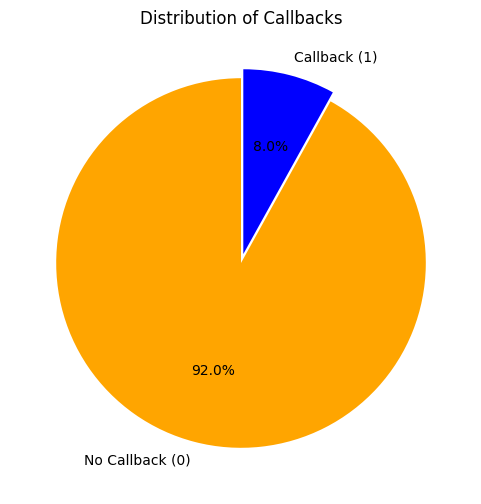

In [4]:
# 2. Target variable distribution: received_callback 
import matplotlib.pyplot as plt

# Count values
callback_counts = data['received_callback'].value_counts()

# Labels for the pie
labels = ['No Callback (0)', 'Callback (1)']
colors = ['orange', 'blue']

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    callback_counts,
    labels=labels,
    autopct='%1.1f%%',  # show percentages
    startangle=90,      # rotate so it starts at the top
    colors=colors,
    explode=(0, 0.05)   # slightly explode the callback slice
)
plt.title("Distribution of Callbacks")
plt.show()

#### Target Variable Conclusion

The distribution of the target variable `received_callback` is highly imbalanced:

- **No Callback (0): ~92%**
- **Callback (1): ~8%**

This means that only a small fraction of applicants in the dataset actually received a callback.  
Such an imbalance is important to keep in mind, because:

- Accuracy alone would be misleading (a model predicting “no callback” for everyone would still achieve 92% accuracy).  
- More informative metrics such as **precision, recall, F1-score, and ROC-AUC** should be used to evaluate models.  
- Techniques like **SMOTE (Synthetic Minority Oversampling Technique)** or other resampling methods **Bayesian bootstrapping** is going to be used to ensure the model learns to identify the minority class (so the callback group) effectively.

The previous authors utilized logistic regression to combat the imbalance so I won't be replicating these results since it's already been done. 


job_req_min_experience    2746
job_fed_contractor        1768
job_city                     0
job_industry                 0
job_type                     0
job_ad_id                    0
job_equal_opp_employer       0
job_ownership                0
job_req_communication        0
job_req_any                  0
job_req_education            0
job_req_computer             0
job_req_organization         0
job_req_school               0
received_callback            0
firstname                    0
race                         0
gender                       0
years_college                0
college_degree               0
honors                       0
worked_during_school         0
years_experience             0
computer_skills              0
special_skills               0
volunteer                    0
military                     0
employment_holes             0
has_email_address            0
resume_quality               0
dtype: int64


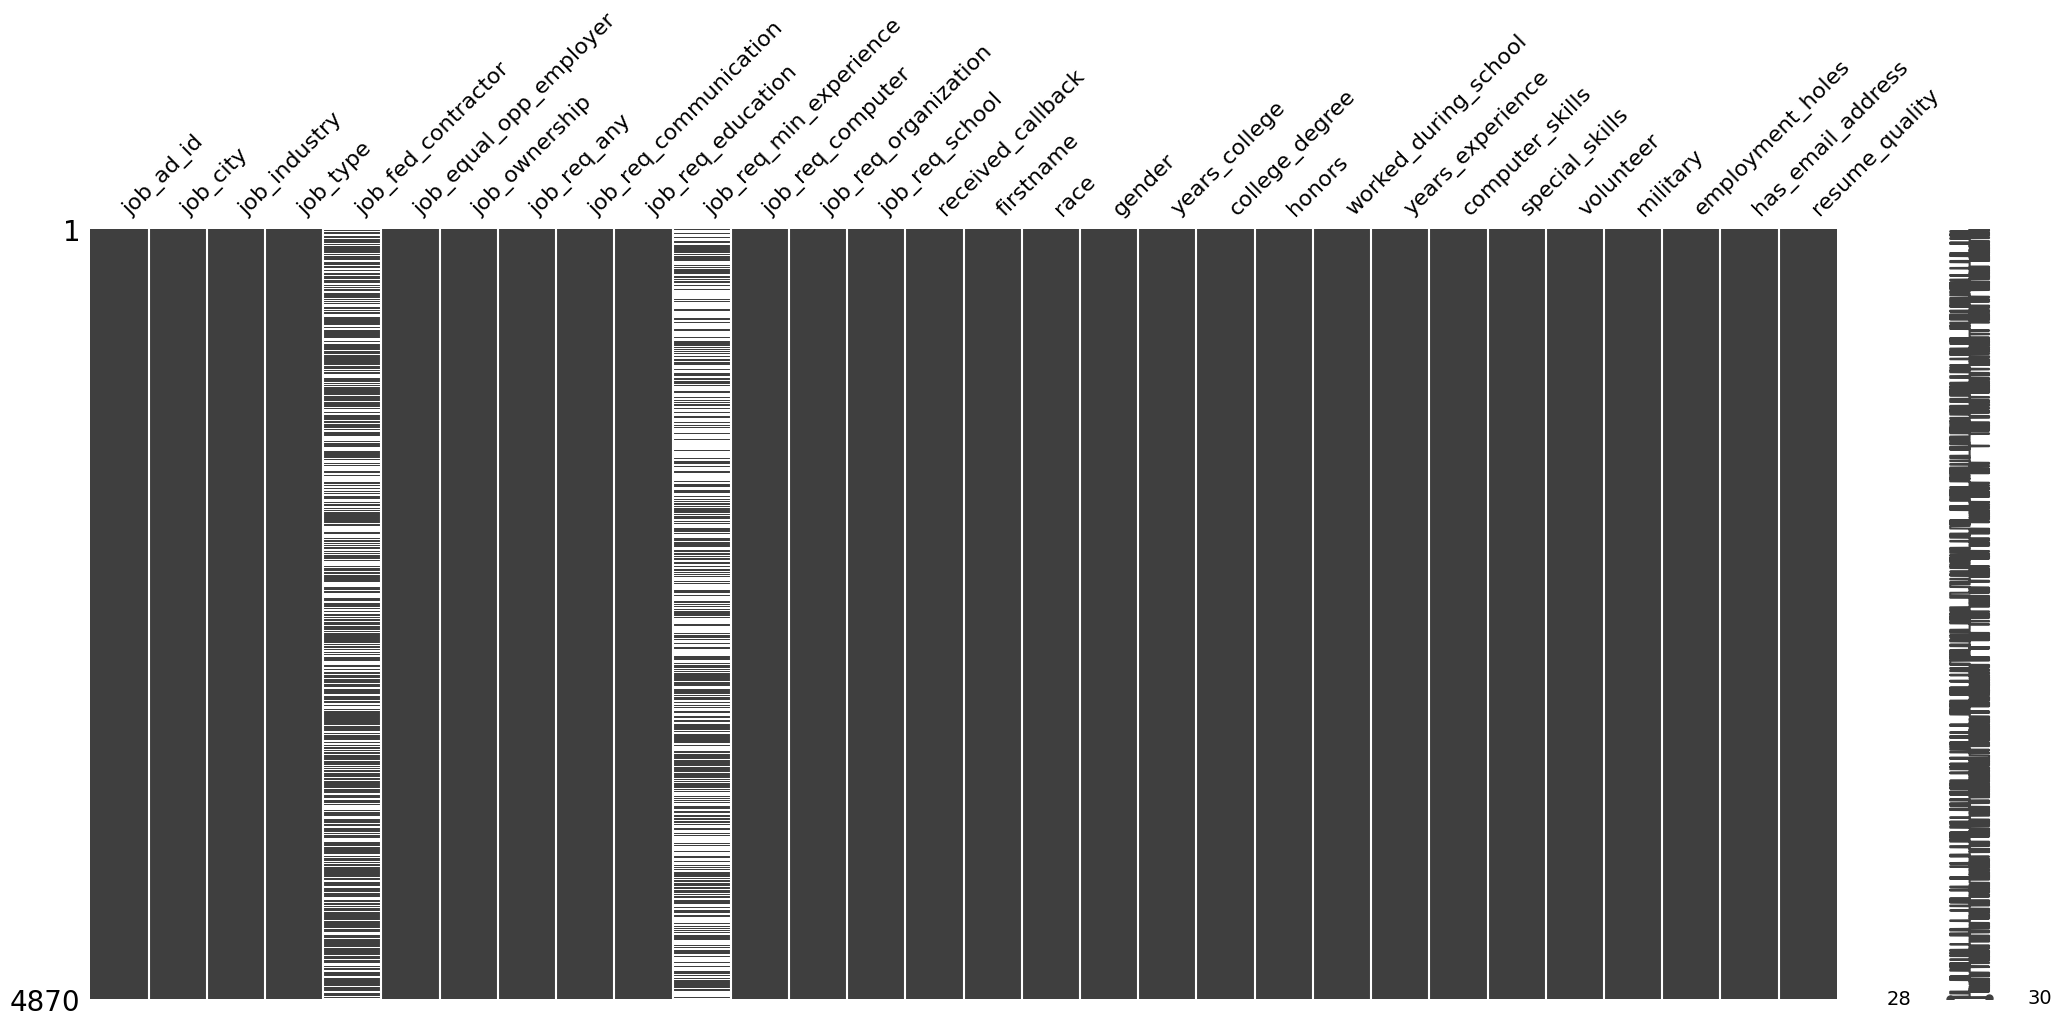

In [5]:
# 3. Missing values 
import missingno as msno  

print(data.isnull().sum().sort_values(ascending=False))

msno.matrix(data)
plt.show()

#### Missing Values Conclusion

The dataset is overall very complete:  
- Most columns have 0 missing values  
- Only two variables contain missing data:
  - **`job_req_min_experience`** → 2,746 missing (~56%).  
  - **`job_fed_contractor`** → 1,768 missing (~36%).  

These missing values are not necessarily errors. In the context of job postings:  
- If `job_req_min_experience` is missing, it likely means the employer did not specify a minimum experience requirement.  
- If `job_fed_contractor` is missing, it likely means the job ad did not mention contractor status.  

### Implications for Modeling
- Both columns can be kept by treating “missing” as meaningful information (e.g., add a category `"Unknown"`).  
- This avoids dropping valuable rows while still capturing the fact that some ads leave these details unspecified which seems to be what the other authors have done too. 
- Since all other columns are fully complete, no large-scale imputation is needed. 



--- job_city ---
job_city
Chicago    2704
Boston     2166
Name: count, dtype: int64


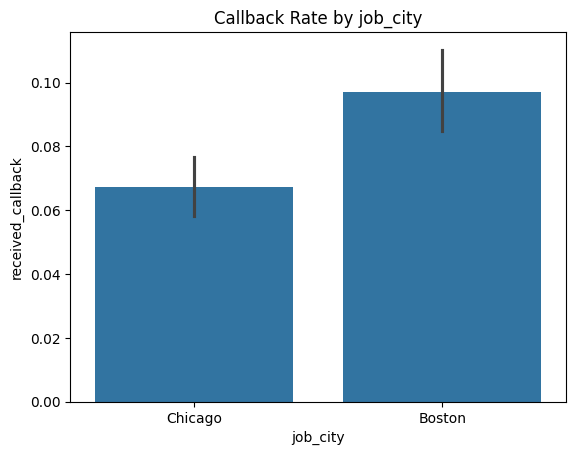


--- job_industry ---
job_industry
other_service                    1558
business_and_personal_service    1304
wholesale_and_retail_trade       1042
finance_insurance_real_estate     414
manufacturing                     404
Name: count, dtype: int64


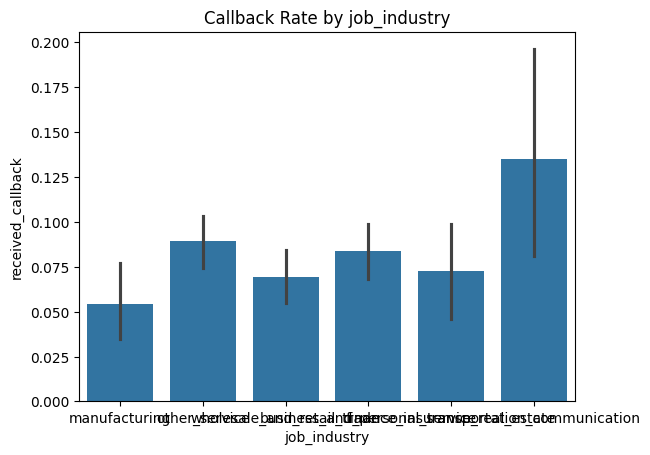


--- job_type ---
job_type
secretary       1621
retail_sales     818
manager          741
sales_rep        736
clerical         578
Name: count, dtype: int64


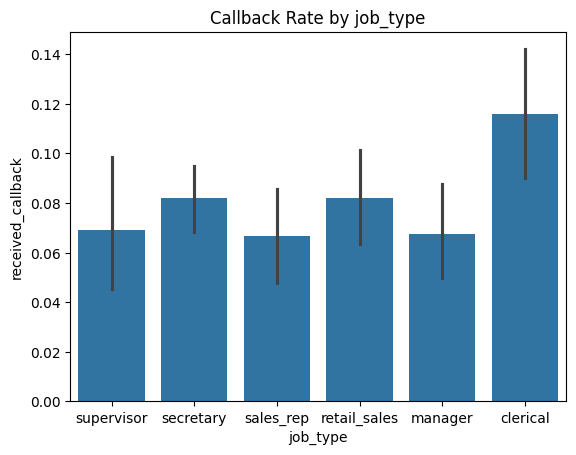


--- job_ownership ---
job_ownership
private      2134
unknown      1992
public        426
nonprofit     318
Name: count, dtype: int64


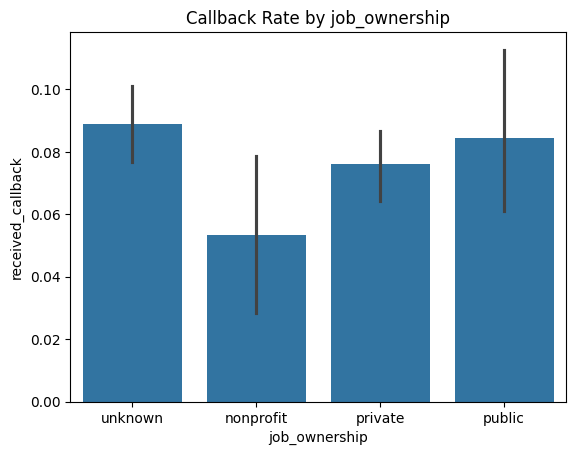


--- job_req_min_experience ---
job_req_min_experience
some    1064
2        356
3        331
5        163
1        142
Name: count, dtype: int64

--- job_req_school ---
job_req_school
none_listed         4350
some_college         252
college              222
high_school_grad      46
Name: count, dtype: int64


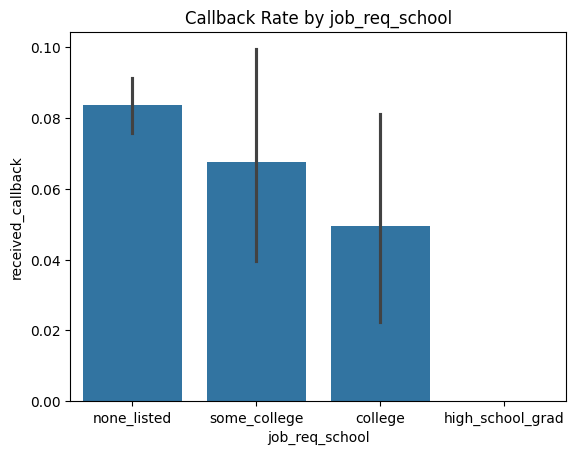


--- firstname ---
firstname
Tamika     256
Anne       242
Allison    232
Latonya    230
Emily      227
Name: count, dtype: int64

--- race ---
race
white    2435
black    2435
Name: count, dtype: int64


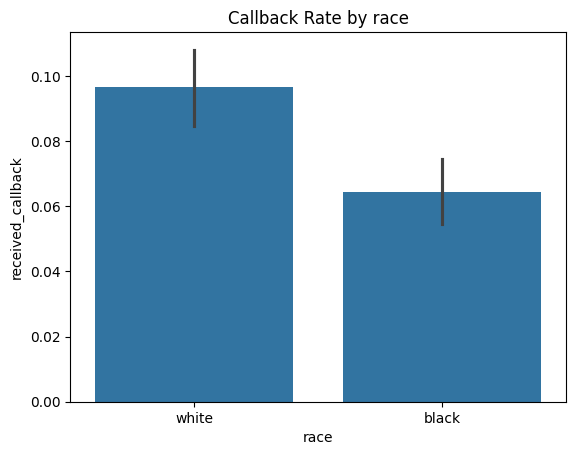


--- gender ---
gender
f    3746
m    1124
Name: count, dtype: int64


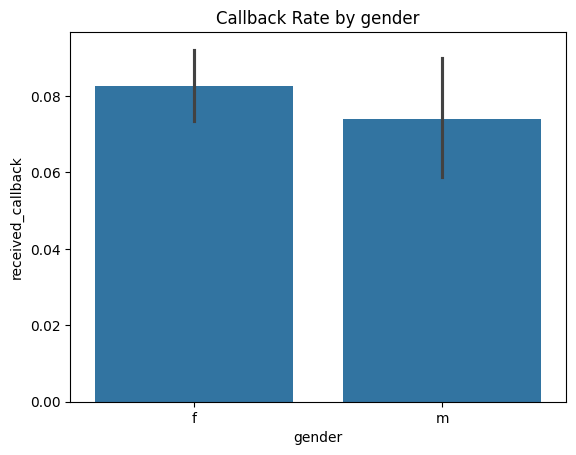


--- resume_quality ---
resume_quality
high    2446
low     2424
Name: count, dtype: int64


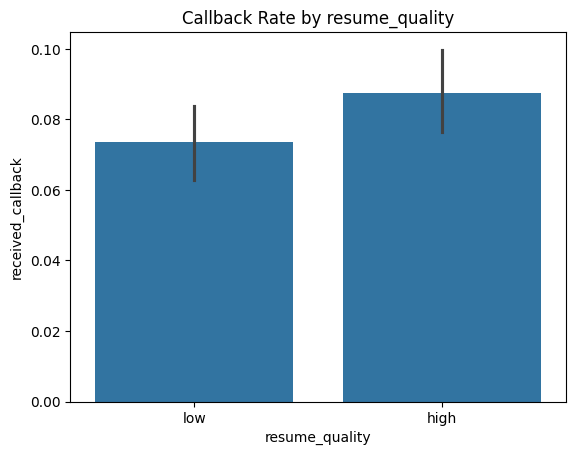

In [6]:
# 4. Categorical feature analysis 
# Looking at frequency counts of categorical features and their relationship with the target variable
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = data.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(data[col].value_counts().head())

    # Plot callback rate by category (only if few categories)
    if data[col].nunique() < 10:
        sns.barplot(x=col, y="received_callback", data=data)
        plt.title(f"Callback Rate by {col}")
        plt.show()


In [8]:
# Check how many males vs females there were:
print(data['gender'].value_counts())

# And see percentages
print(data['gender'].value_counts(normalize=True) * 100)

gender
f    3746
m    1124
Name: count, dtype: int64
gender
f    76.919918
m    23.080082
Name: proportion, dtype: float64


#### Categorical Features – Conclusion

The callback rate varies across several categorical variables:

- **Job City**:  
  - Applicants in **Boston** had a higher callback rate (~10%) compared to **Chicago** (~7%).  
  - Suggests location played a role in employer responsiveness.  

- **Job Industry**:  
  - **Transportation/communication** jobs showed the highest callback rates (~13%).  
  - **Manufacturing** had the lowest (~5%).  
  - Other industries fell in between (~7–9%).  

- **Job Type**:  
  - **Clerical positions** had the highest callback rate (~12%).  
  - Other types like sales or managerial roles hovered around 7–8%.  

- **Job Ownership**:  
  - **Nonprofit jobs** had the lowest callback rate (~5%).  
  - **Unknown/public/private** jobs had similar rates (~8–9%).  

- **Job School Requirement**:  
  - Surprisingly, ads with **no school requirement listed** had the highest callback rates (~8–9%).  
  - Jobs explicitly requiring **college** had lower callback rates (~5%).  

- **Race**:  
  - Applicants with **White-sounding names** had a callback rate of ~10%.  
  - Applicants with **Black-sounding names** had a lower callback rate of ~6–7%.  
  - This aligns with previous findings that the dataset highlights racial discrimination in callbacks.  

- **Gender**:  
  - **Female** applicants had a slightly higher callback rate (~8%) than **male** applicants (~7%).  
  - The difference is small compared to race effects.  
  - Important to note that there were more female applicants (3746) than male applicants (1124). 

- **Resume Quality**:  
  - **High-quality resumes** received more callbacks (~9%) than **low-quality** ones (~7%).  
  - Resume strength is a relevant predictor, though not as strong as demographic variables.  

### Overall Insights 
- Race emerges as the clearest bias, with White applicants receiving callbacks at higher rates than Black applicants. This could be a bias in the way the model learns.
- Resume quality and job characteristics (industry, type, city) also seem to influence the chances of receiving a callback which makes sense.


Continuous Variables: ['years_college', 'years_experience', 'job_fed_contractor']


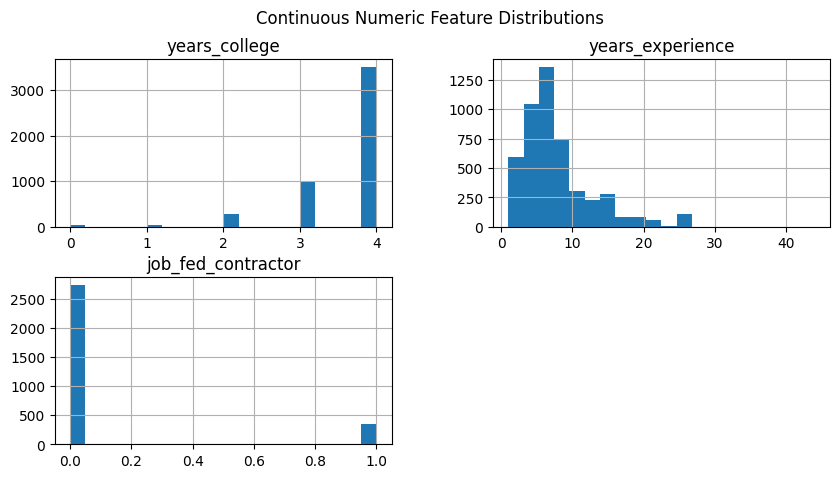

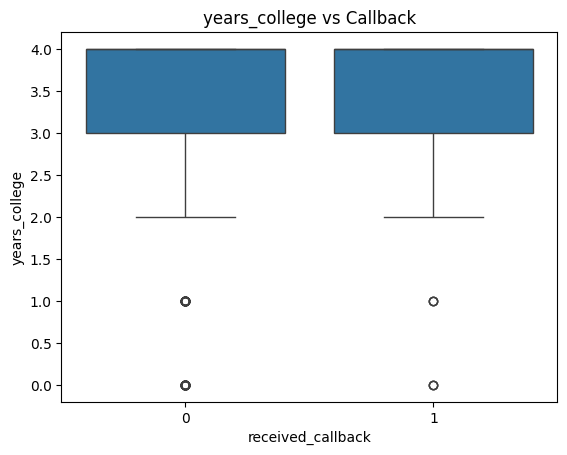

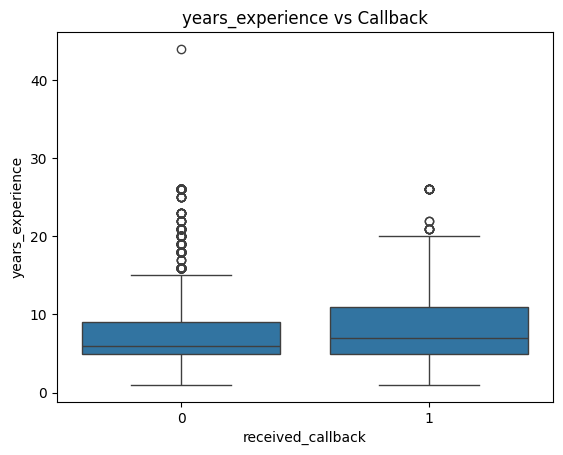

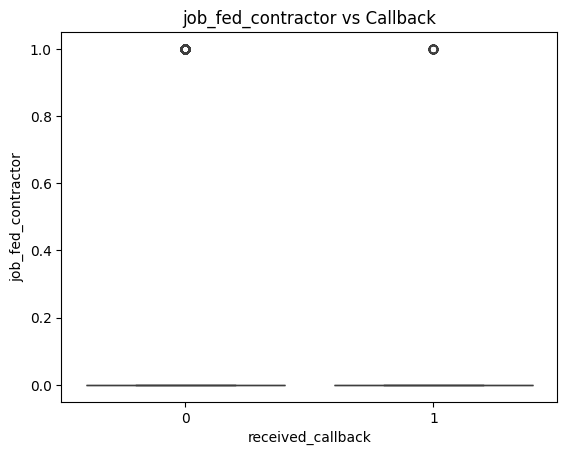

Binary Variables: ['job_ad_id', 'job_equal_opp_employer', 'job_req_any', 'job_req_communication', 'job_req_education', 'job_req_computer', 'job_req_organization', 'college_degree', 'honors', 'worked_during_school', 'computer_skills', 'special_skills', 'volunteer', 'military', 'employment_holes', 'has_email_address']


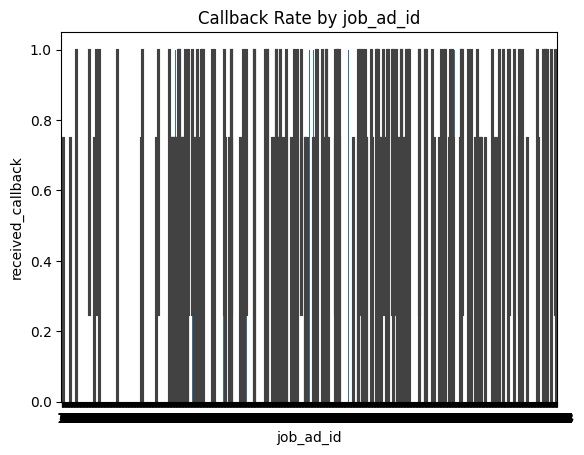

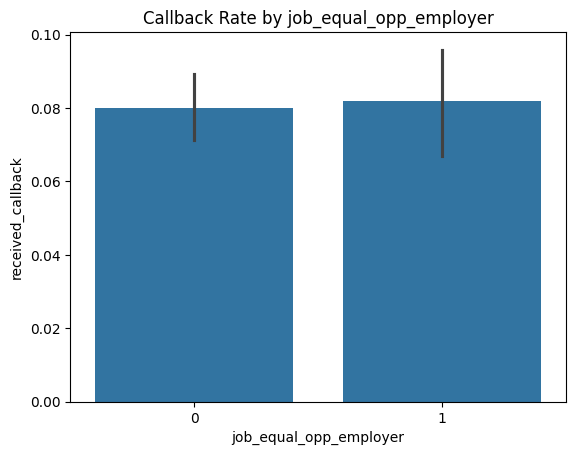

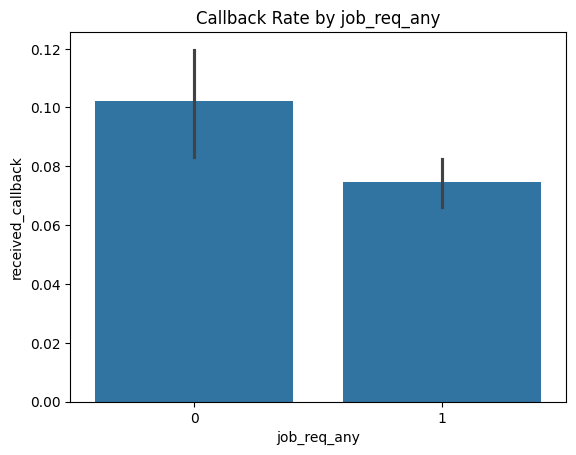

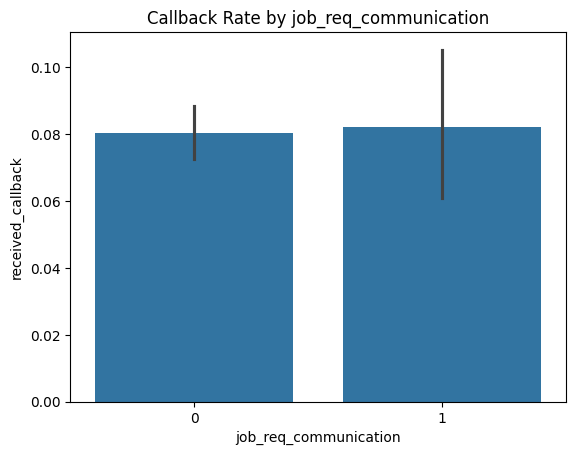

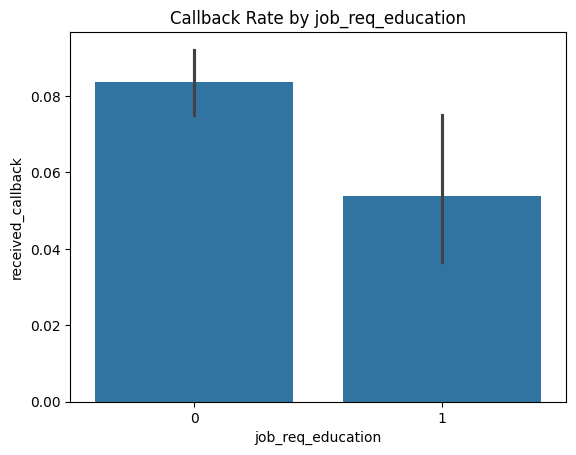

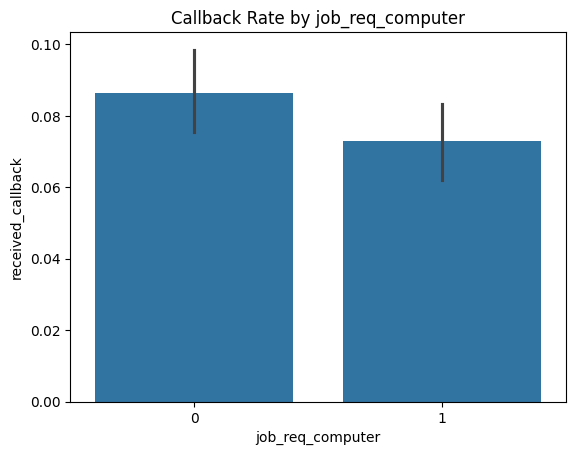

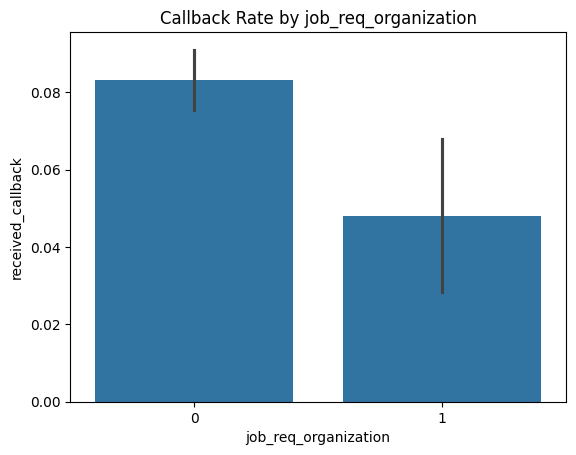

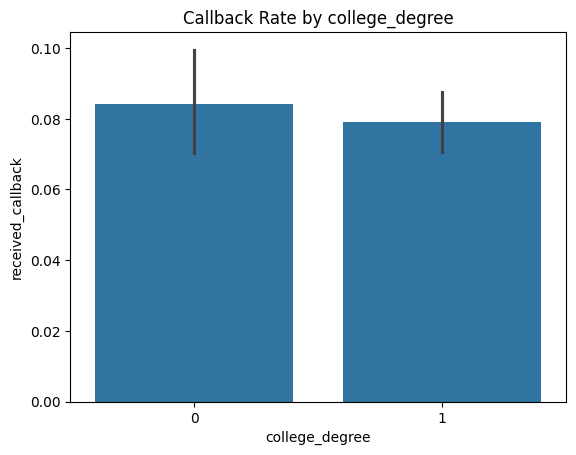

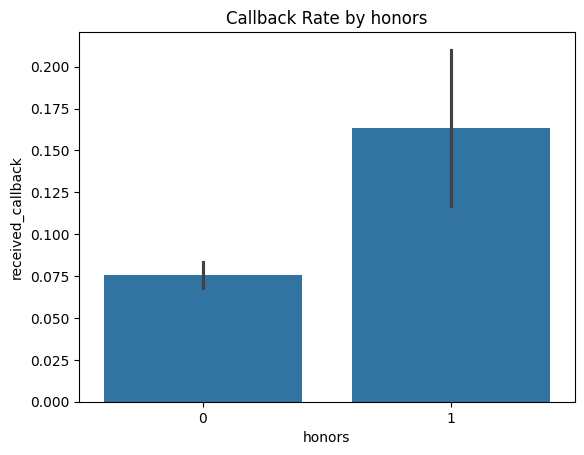

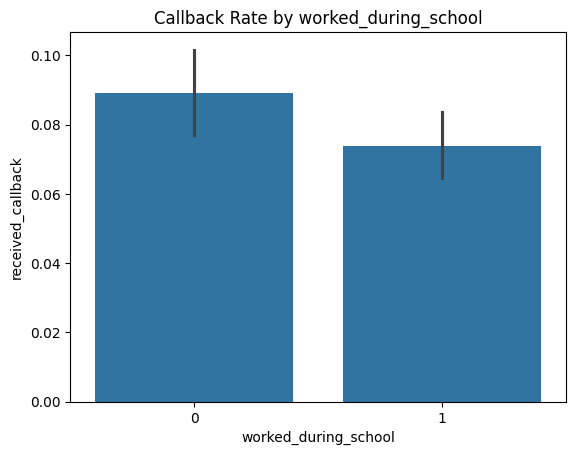

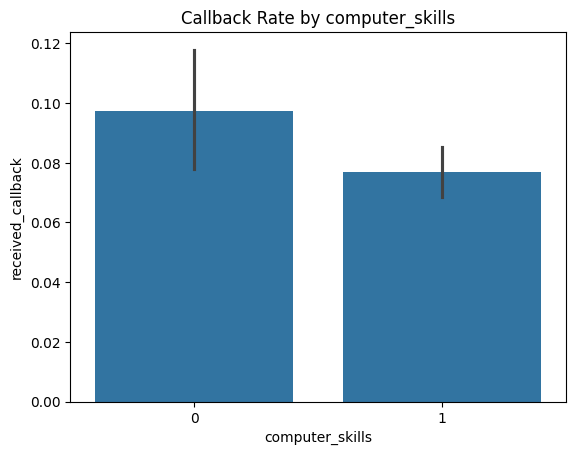

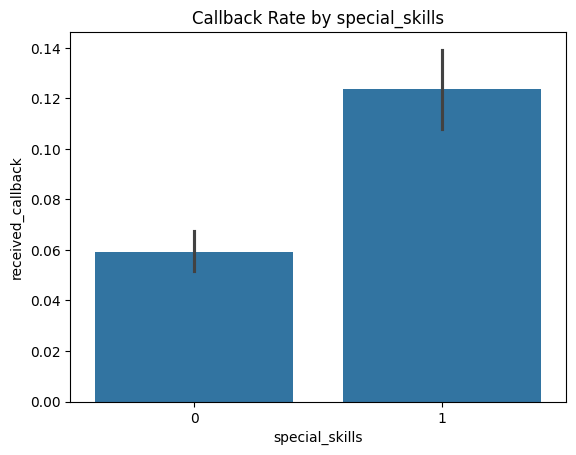

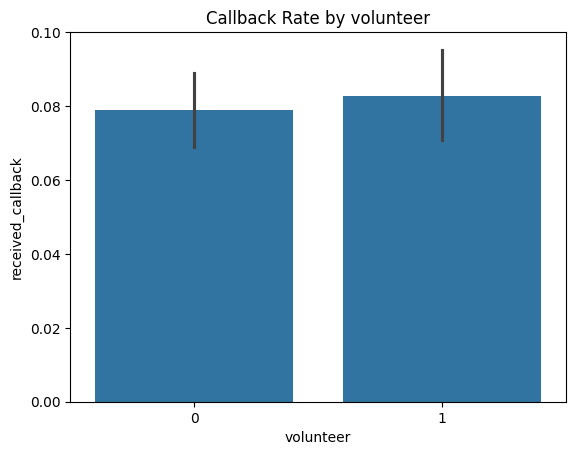

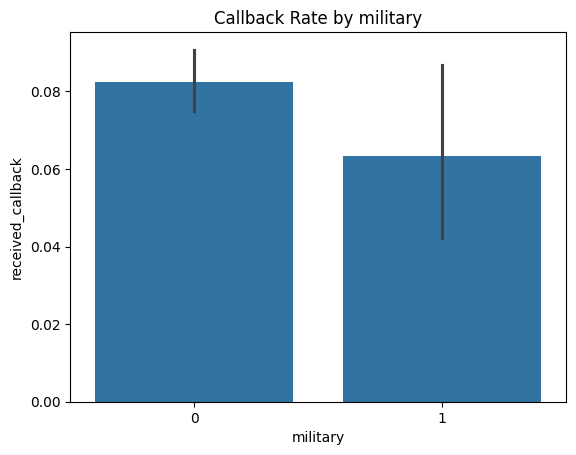

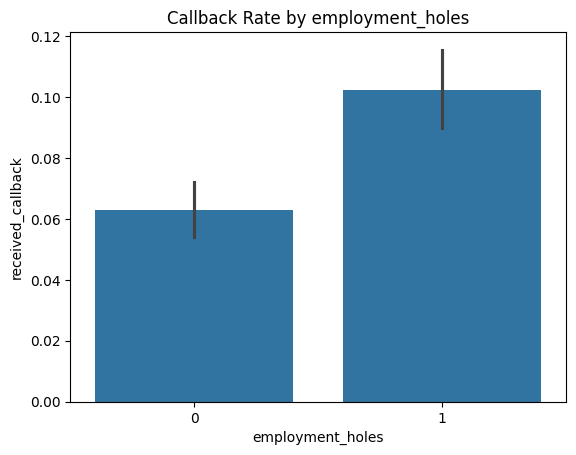

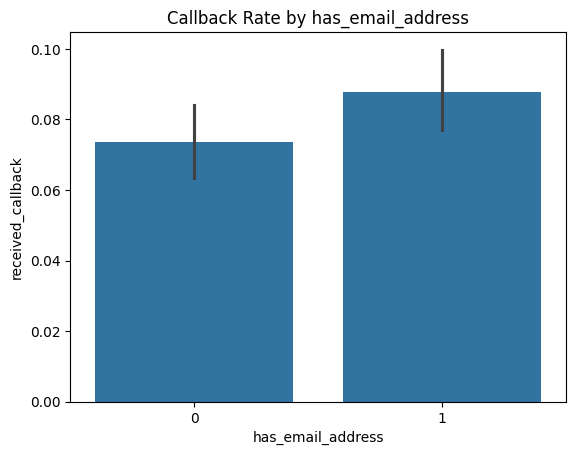

In [9]:
# 5. Numerical feature analysis

# Identify numeric columns (excluding target)
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns.drop("received_callback")

# Separate continuous vs binary
continuous_cols = ['years_college', 'years_experience', 'job_fed_contractor']
binary_cols = [col for col in numeric_cols if col not in continuous_cols]

# --- Continuous Variables ---
print("Continuous Variables:", continuous_cols)

# Histograms for continuous variables
data[continuous_cols].hist(figsize=(10, 5), bins=20)
plt.suptitle("Continuous Numeric Feature Distributions")
plt.show()

# Boxplots vs target
for col in continuous_cols:
    sns.boxplot(x="received_callback", y=col, data=data)
    plt.title(f"{col} vs Callback")
    plt.show()

# --- Binary Variables ---
print("Binary Variables:", binary_cols)

# Barplots of proportion of callbacks for each binary feature
for col in binary_cols:
    sns.barplot(x=col, y="received_callback", data=data)
    plt.title(f"Callback Rate by {col}")
    plt.show()


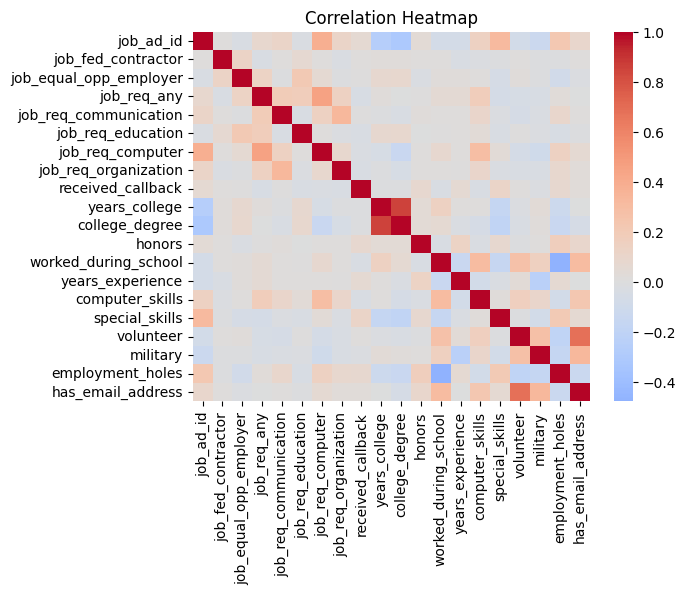

In [10]:
# 6. Numerical features - Correlation
corr = data.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


#### Numeric Features – Conclusion

**Continuous variables:**
- **Years of College**: Most applicants had the maximum coded value of 4 (equivalent to finishing college). Callback rates do not differ much by years of college.  
- **Years of Experience**: Applicants with callbacks had slightly higher experience on average, but the difference is modest. Outliers with 20+ years of experience did not guarantee higher callbacks.  
- **Job Fed Contractor**: Very few job ads mention federal contractor status. This variable is heavily skewed so when doing an interpretation it's probably not a real predictor.   

**Job-related binary variables:**
- **Equal Opportunity Employer**: No meaningful difference in callbacks between EOE and non-EOE postings.  
- **General Requirements (`job_req_any`)**: Ads with *no* general requirements had higher callback rates (~10%) than those that did (~7%).  
- **Specific Requirements (`job_req_education`, `job_req_computer`, `job_req_organization`)**: Callback rates were consistently *lower* when these requirements were listed. Employers listing more requirements seemed to generate fewer callbacks.  
- **College Degree Requirement**: Having a degree requirement did not significantly change callback rates.  

**Applicant-related binary variables:**
- **Honors**: Applicants listing honors had a much higher callback rate (~16%) compared to those without (~8%).  
- **Worked During School**: Slightly lower callback rates when applicants worked during school (~7%) versus those who did not (~9%).  
- **Computer Skills**: Listing computer skills was associated with lower callback rates (~8%) compared to not listing them (~10%).  
- **Special Skills**: Applicants who listed special skills had significantly higher callback rates (~12%) compared to those who did not (~6%).  
- **Volunteering**: Very little difference between volunteers and non-volunteers.  
- **Military Experience**: Applicants with military backgrounds had slightly lower callback rates (~6%) compared to those without (~8%).  
- **Employment Holes**: Surprisingly, applicants with gaps in their work history had *higher* callback rates (~10%) compared to those with continuous employment (~6%).  
- **Has Email Address**: Applicants who listed an email had a higher callback rate (~9%) compared to those without (~7%).  

### Overall Insights
- **Honors and special skills** stand out as strong positive predictors of callbacks.  
- **Employment gaps** unexpectedly correlated with higher callbacks — possibly because these resumes still had compensating strengths.  
- **Listing many requirements (education, organization, computer)** at the job level seems to *reduce* callback chances.  
- **Resume details matter**: email address, honors, and special skills improve chances, while military service and working during school do not  
- Taken together, applicant features (resume quality, honors, skills) seem more predictive of callbacks than most job requirements.  


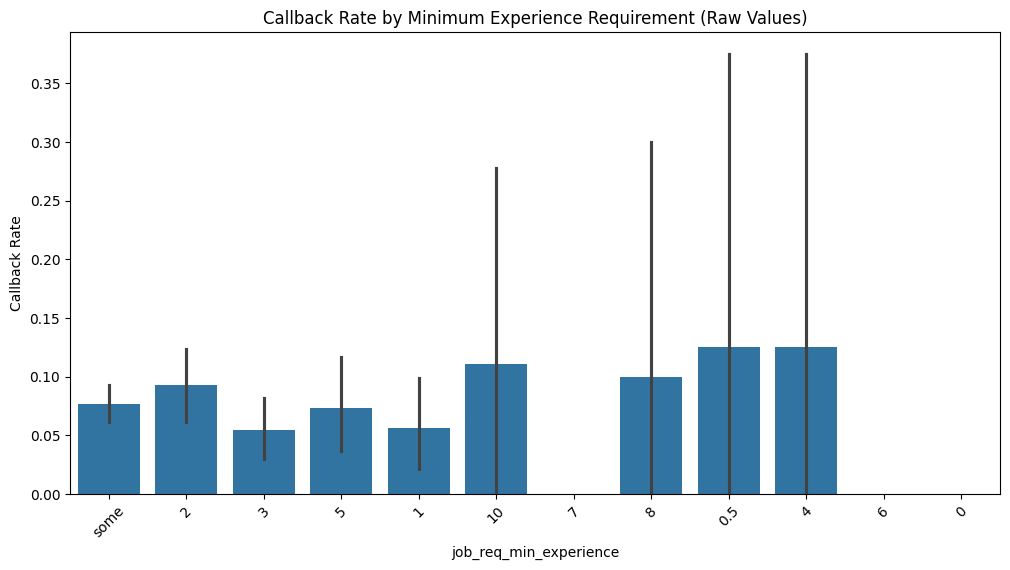

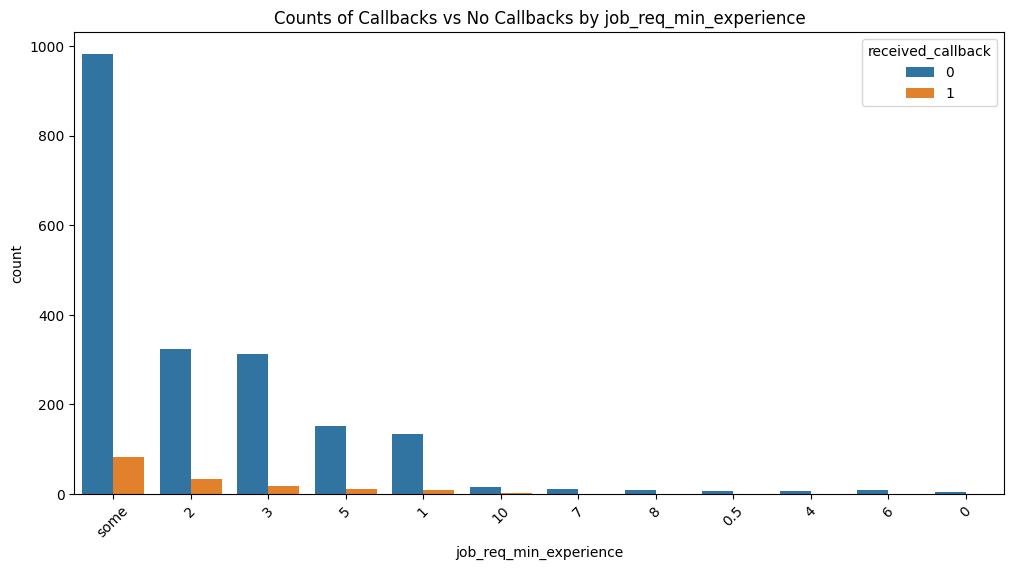

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Barplot of callback rates by raw job_req_min_experience
plt.figure(figsize=(12,6))
sns.barplot(
    x="job_req_min_experience",
    y="received_callback",
    data=data,
    estimator="mean",
    order=data["job_req_min_experience"].value_counts().index  # sort by frequency
)
plt.xticks(rotation=45)
plt.title("Callback Rate by Minimum Experience Requirement (Raw Values)")
plt.ylabel("Callback Rate")
plt.xlabel("job_req_min_experience")
plt.show()

# Optional: countplot to see distribution
plt.figure(figsize=(12,6))
sns.countplot(
    x="job_req_min_experience",
    hue="received_callback",
    data=data,
    order=data["job_req_min_experience"].value_counts().index
)
plt.xticks(rotation=45)
plt.title("Counts of Callbacks vs No Callbacks by job_req_min_experience")
plt.show()


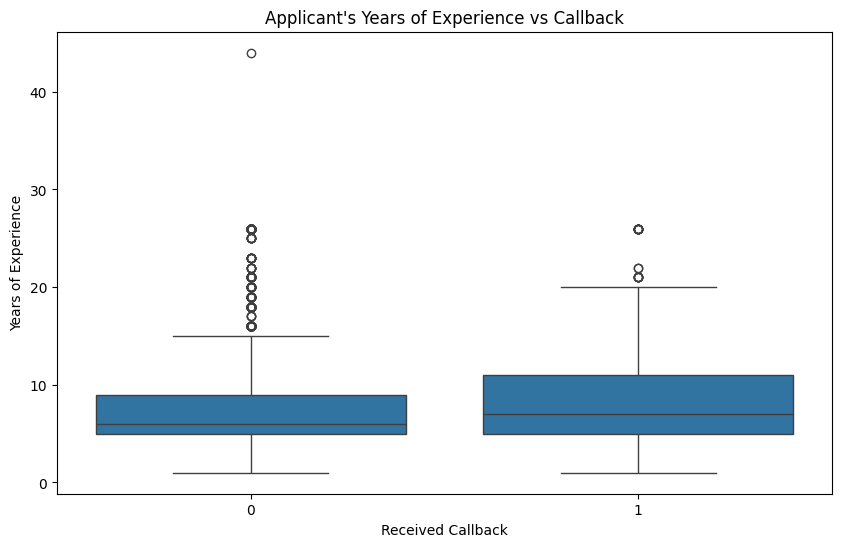

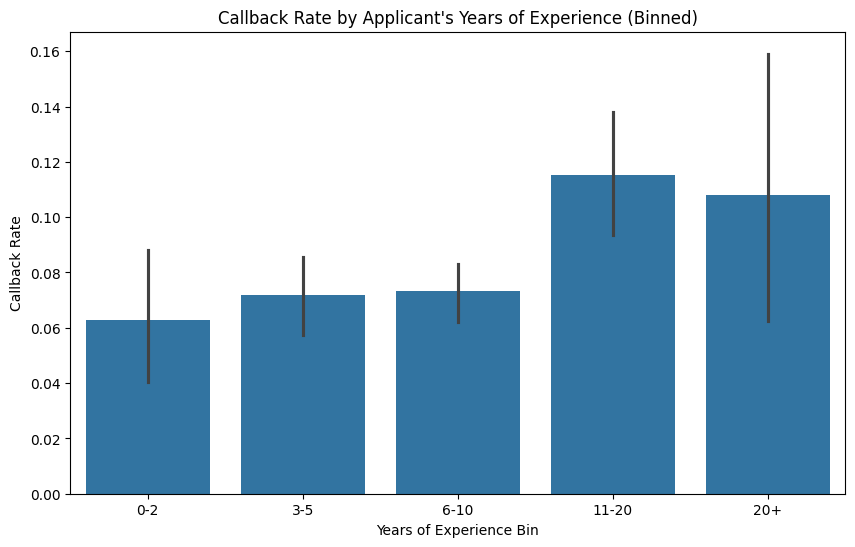

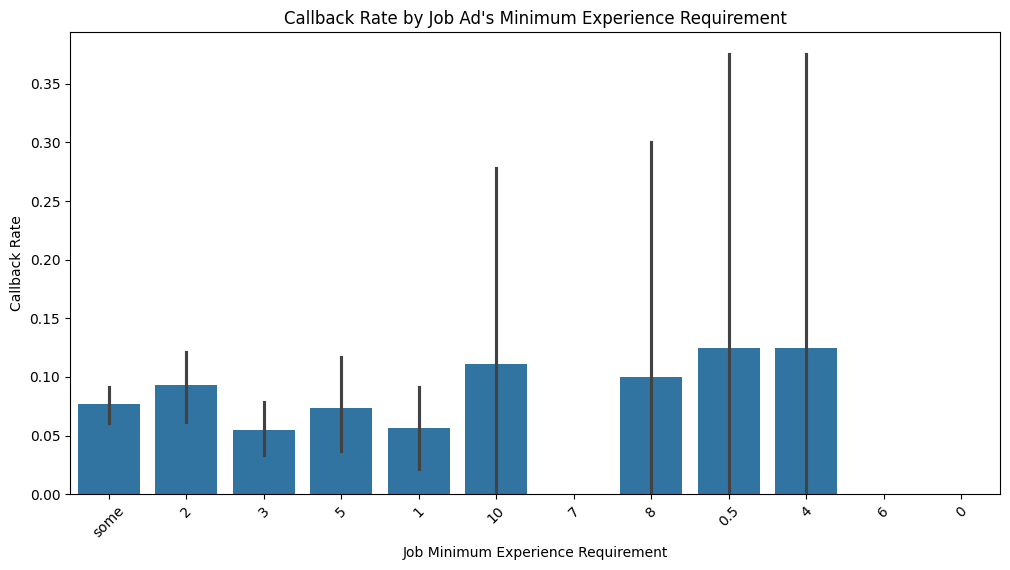

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Applicant actual years of experience 
plt.figure(figsize=(10,6))
sns.boxplot(x="received_callback", y="years_experience", data=data)
plt.title("Applicant's Years of Experience vs Callback")
plt.ylabel("Years of Experience")
plt.xlabel("Received Callback")
plt.show()

# Optional: average callback rate by applicant's experience bins
data['exp_bin'] = pd.cut(data['years_experience'], bins=[0,2,5,10,20,50], labels=['0-2','3-5','6-10','11-20','20+'])
plt.figure(figsize=(10,6))
sns.barplot(x="exp_bin", y="received_callback", data=data, estimator="mean")
plt.title("Callback Rate by Applicant's Years of Experience (Binned)")
plt.ylabel("Callback Rate")
plt.xlabel("Years of Experience Bin")
plt.show()

# 2. Employer's required minimum experience 
plt.figure(figsize=(12,6))
sns.barplot(
    x="job_req_min_experience",
    y="received_callback",
    data=data,
    estimator="mean",
    order=data["job_req_min_experience"].value_counts().index
)
plt.xticks(rotation=45)
plt.title("Callback Rate by Job Ad's Minimum Experience Requirement")
plt.ylabel("Callback Rate")
plt.xlabel("Job Minimum Experience Requirement")
plt.show()


## Section 2: Data Preprocessing

Before we can build predictive models, we must address some important issues in the dataset.    

### Main Challenges
I identified **three main problems** in the dataset that need to be addressed:

1. **Missing Values**  
   - Columns like `job_req_min_experience` and `job_fed_contractor` contain missing or ambiguous entries.  
   - I will carefully treat these by creating meaningful categories (e.g., `"Unknown"`, `"Some"`) instead of imputing arbitrary numbers (as done by the other authors who replaced "some" with 0.5 years and assumed that "unknown" meant 0 experience required). 

2. **Categorical Values Transformation**  
   - Many features (e.g., `job_city`, `job_industry`, `gender`, `race`) are categorical.  
   - Machine learning models require numeric inputs, so we will apply **one-hot encoding** for nominal variables and keep binary indicators as they are. This is done as part of the next section to avoid any mistakes. 

3. **Class Imbalance** *(to be discussed in the next section)*  
   - The target variable `received_callback` is highly imbalanced (~92% no-callback vs. ~8% callback).  
   - This can bias models to always predict the majority class, hence have a very high accuracy which can be misleading. 
   - In the next section, we will discuss strategies such as resampling (SMOTE, bayesian boot strapping) to handle this imbalance.  

N.B.: Before doing anything to adjust the data, I will split them into train and test set to avoid any data leakage. 

### Test/Train Split 
Before applying any preprocessing (especially handling missing values or encoding), we first split the dataset into training and testing sets.  
This avoids data leakage so that the model only learns patterns from the training data and is fairly evaluated on unseen data test set.

We will use an 80/20 split with stratification on the target (`received_callback`) to maintain class balance since it's really unfairly distributed already and we don't want to end up with 0 callbacks in the test set since this is our target variable.

In [14]:
# Make a safe copy of the raw data and perform a stratified train/test split
# - Reads `resume.csv` from the current folder
# - Makes a copy so raw data isn't overwritten
# - Performs stratified split on `received_callback` to preserve class proportions
# - Saves `resume_train.csv` and `resume_test.csv` in the same folder

import os
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_PATH = 'Resources/resume.csv'  # adjust if your file has a different path
TRAIN_OUT = 'Resources/resume_train.csv'
TEST_OUT = 'Resources/resume_test.csv'

# Load
raw = pd.read_csv(DATA_PATH)
print(f"Loaded raw data: {raw.shape[0]} rows, {raw.shape[1]} cols")

# Make a copy to work on
df = raw.copy()

if 'received_callback' not in df.columns:
    raise KeyError("`received_callback` column not found in the dataset.")

# Show class distribution
print('\nOverall class distribution:')
print(df['received_callback'].value_counts(normalize=True).mul(100).round(2))

# Stratified split: keep the small class proportion in both train/test
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['received_callback'],
    random_state=42
)

# Save outputs
train_df.to_csv(TRAIN_OUT, index=False)
test_df.to_csv(TEST_OUT, index=False)

print(f"\nSaved train -> {TRAIN_OUT} ({train_df.shape[0]} rows)")
print(f"Saved test  -> {TEST_OUT} ({test_df.shape[0]} rows)")

# Verify distributions
print('\nTrain class distribution:')
print(train_df['received_callback'].value_counts(normalize=True).mul(100).round(2))
print('\nTest class distribution:')
print(test_df['received_callback'].value_counts(normalize=True).mul(100).round(2))

Loaded raw data: 4870 rows, 30 cols

Overall class distribution:
received_callback
0    91.95
1     8.05
Name: proportion, dtype: float64

Saved train -> Resources/resume_train.csv (3896 rows)
Saved test  -> Resources/resume_test.csv (974 rows)

Train class distribution:
received_callback
0    91.94
1     8.06
Name: proportion, dtype: float64

Test class distribution:
received_callback
0    91.99
1     8.01
Name: proportion, dtype: float64


In [15]:
# Clean specific columns in train/test sets
# - Loads `resume_train.csv` and `resume_test.csv` if present (created previously by the split)
# - Falls back to creating an 80/20 stratified split from `resume.csv` if those files are missing
# - Applies the requested treatments for `job_req_min_experience` and `job_fed_contractor`
# - Drops irrelevant columns for the research and saves cleaned CSVs

import os
import pandas as pd

def load_or_create_splits():
    """Load existing train/test CSVs if present, otherwise create stratified splits from resume.csv."""
    if os.path.exists(TRAIN_OUT) and os.path.exists(TEST_OUT):
        X_train = pd.read_csv(TRAIN_OUT)
        X_test = pd.read_csv(TEST_OUT)
        print(f"Loaded existing {TRAIN_OUT} and {TEST_OUT} (cwd={os.getcwd()})")
    else:
        # create split from resume.csv
        from sklearn.model_selection import train_test_split
        if not os.path.exists('resume.csv'):
            raise FileNotFoundError('Neither train/test CSVs nor resume.csv were found in the current folder.')
        df = pd.read_csv('resume.csv')
        if 'received_callback' not in df.columns:
            raise KeyError('Column `received_callback` is missing from resume.csv; cannot create stratified split.')
        X_train, X_test = train_test_split(df, test_size=0.2, stratify=df['received_callback'], random_state=42)
        X_train.to_csv(TRAIN_OUT, index=False)
        X_test.to_csv(TEST_OUT, index=False)
        print(f"Created and saved {TRAIN_OUT} and {TEST_OUT} from resume.csv")
    return X_train, X_test

X_train_clean, X_test_clean = load_or_create_splits()

# 1. Handle job_req_min_experience
col1 = 'job_req_min_experience'
if col1 in X_train_clean.columns:
    X_train_clean[col1] = X_train_clean[col1].fillna('Unknown').astype(str)
    X_test_clean[col1] = X_test_clean[col1].fillna('Unknown').astype(str)
    print(f"Handled {col1}: filled NA with 'Unknown' and cast to str")
else:
    print(f"Warning: column '{col1}' not found. Skipping this step.")

# 2. Handle job_fed_contractor
col2 = 'job_fed_contractor'
if col2 in X_train_clean.columns:
    # If values are booleans or floats, convert to int (0/1) after filling NA with 0
    X_train_clean[col2] = X_train_clean[col2].fillna(0).astype(int)
    X_test_clean[col2] = X_test_clean[col2].fillna(0).astype(int)
    print(f"Handled {col2}: filled NA with 0 and cast to int")
else:
    print(f"Warning: column '{col2}' not found. Skipping this step.")

# 3. Drop irrelevant columns for the research and save cleaned files
DROP_COLS = ['job_ad_id', 'first_name']

dropped_train = [c for c in DROP_COLS if c in X_train_clean.columns]
if dropped_train:
    X_train_clean = X_train_clean.drop(columns=dropped_train)

dropped_test = [c for c in DROP_COLS if c in X_test_clean.columns]
if dropped_test:
    X_test_clean = X_test_clean.drop(columns=dropped_test)

print(f"Dropped columns from train: {dropped_train}")
print(f"Dropped columns from test: {dropped_test}")

# Save cleaned sets
TRAIN_CLEAN_OUT = 'resume_train_clean.csv'
TEST_CLEAN_OUT = 'resume_test_clean.csv'
X_train_clean.to_csv(TRAIN_CLEAN_OUT, index=False)
X_test_clean.to_csv(TEST_CLEAN_OUT, index=False)
print(f"Saved cleaned train/test as {TRAIN_CLEAN_OUT} and {TEST_CLEAN_OUT}")

# Quick missing-value check
print('\nMissing values after treatment (train):')
print(X_train_clean.isnull().sum().sort_values(ascending=False).head())
print('\nMissing values after treatment (test):')
print(X_test_clean.isnull().sum().sort_values(ascending=False).head())


Loaded existing Resources/resume_train.csv and Resources/resume_test.csv (cwd=c:\Users\Nehir Imal\OneDrive\Documents\UNIVERSITY\Masters\MSB1015\Project\OpenIntro-Resume_Data-Analysis-main\OpenIntro-Resume_Data-Analysis-main)
Handled job_req_min_experience: filled NA with 'Unknown' and cast to str
Handled job_fed_contractor: filled NA with 0 and cast to int
Dropped columns from train: ['job_ad_id']
Dropped columns from test: ['job_ad_id']
Saved cleaned train/test as resume_train_clean.csv and resume_test_clean.csv

Missing values after treatment (train):
job_city                  0
job_industry              0
job_type                  0
job_fed_contractor        0
job_equal_opp_employer    0
dtype: int64

Missing values after treatment (test):
job_city                  0
job_industry              0
job_type                  0
job_fed_contractor        0
job_equal_opp_employer    0
dtype: int64


## Section 3: Handling Class Imbalance

Our target variable `received_callback` is highly imbalanced:
- ~92% of applicants received **no callback**.
- ~8% received a **callback**.

This imbalance can cause predictive models to always predict the majority class (“no callback”) and still achieve high accuracy, while completely failing to identify the minority class (callbacks).

### Strategies to Address Class Imbalance

1. **Resampling Methods**
   - **SMOTE (Synthetic Minority Oversampling Technique):**
     Creates synthetic examples of the minority class by interpolating between existing minority samples.
     This increases the number of callback cases and balances the dataset.


2. **Bayesian Bootstrapping**
   - Instead of resampling explicitly, Bayesian bootstrapping assigns *weights* to samples drawn from a Dirichlet distribution.
   - This allows us to model the uncertainty in the minority class without artificially creating or removing observations.
   - We can compare results with SMOTE to see which performs better. 

N.B.: Later on both these methods were combined to see if we could get better model performance. 

3. **Model Evaluation Metrics**
   - Accuracy is misleading here.
   - We will use metrics that are sensitive to imbalance:
     - **Precision** (of predicted callbacks, how many were correct?)
     - **Recall** (of actual callbacks, how many did we find?)
     - **F1-score** (balance of precision and recall)
     - **ROC-AUC** (ability to rank positive vs negative cases)



### SMOTENC pipeline 

This cell builds a pipeline that: 1) scales numeric features and ordinal-encodes categorical features, 2) applies SMOTENC to synthesize minority-class examples for categorical+numeric mix, and 3) fits a logistic regression classifier. It runs 5-fold stratified CV on the training set and then fits the final pipeline and runs a small Bayesian bootstrap on the held-out test set to get metric intervals. 

### Section 3.1: Baseline vs SMOTENC and Bayesian bootsrapping as an alternative
The cutoff values for running logistic regression for this part was re-calculated to have the best one for returning a better F1 since a good F1 determines the fine balance between precision and recall. This was done for all models throughout the entire models since using a fixed cutoff didn't give any results. This can be blamed on the huge class imbalance.

In [16]:
# Section 3.1: Handling Class Imbalance — Baseline and SMOTENC experiment (with best cutoff)

import os, numpy as np, pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC

# Load data
TRAIN_CLEAN, TEST_CLEAN = 'resume_train_clean.csv', 'resume_test_clean.csv'
if not (os.path.exists(TRAIN_CLEAN) and os.path.exists(TEST_CLEAN)):
    raise FileNotFoundError("Clean train/test CSVs not found.")

train, test = pd.read_csv(TRAIN_CLEAN), pd.read_csv(TEST_CLEAN)
TARGET = 'received_callback'
X_train, y_train = train.drop(columns=[TARGET]), train[TARGET]
X_test,  y_test  = test.drop(columns=[TARGET]),  test[TARGET]

# Detect numeric vs categorical
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]
print(f"Numerical cols: {num_cols}")
print(f"Categorical cols: {cat_cols}")

# Helpers
def compute_metrics(y_true, y_pred, y_scores=None):
    return dict(
        precision = precision_score(y_true, y_pred, zero_division=0),
        recall    = recall_score(y_true, y_pred, zero_division=0),
        f1        = f1_score(y_true, y_pred, zero_division=0),
        roc_auc   = roc_auc_score(y_true, y_scores) if y_scores is not None else np.nan
    )

def find_best_cutoff(y_true, y_prob):
    thresholds = np.linspace(0,1,101)
    f1s = [f1_score(y_true,(y_prob>=t).astype(int),zero_division=0) for t in thresholds]
    best_t = thresholds[int(np.argmax(f1s))]
    return best_t, max(f1s)

# Baseline LR
preproc_base = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

baseline_pipe = Pipeline([
    ('pre', preproc_base),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
baseline_pipe.fit(X_train, y_train)
y_prob_base = baseline_pipe.predict_proba(X_test)[:,1]
best_t_base, best_f1_base = find_best_cutoff(y_test, y_prob_base)
y_pred_base = (y_prob_base >= best_t_base).astype(int)
base_metrics = compute_metrics(y_test, y_pred_base, y_prob_base)
base_metrics['best_thresh'] = best_t_base

print("\nBaseline Logistic Regression:")
for k,v in base_metrics.items(): print(f"{k:12s}: {v:.4f}")

# SMOTENC + Logistic Regression 
# Encode categoricals as integers for SMOTENC (OrdinalEncoder)
preproc_smote = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
])
preproc_smote.fit(X_train)
X_train_enc = preproc_smote.transform(X_train)
X_test_enc  = preproc_smote.transform(X_test)

# Identify categorical feature indices
n_num = len(num_cols)
cat_indices = list(range(n_num, n_num + len(cat_cols)))
print(f"Categorical feature indices for SMOTENC: {cat_indices}")

# 2️ Run SMOTENC oversampling
smote = SMOTENC(categorical_features=cat_indices, random_state=42, sampling_strategy=0.4)
X_res, y_res = smote.fit_resample(X_train_enc, y_train)
print(f"\nAfter SMOTENC: training shape {X_res.shape}, class dist: {np.bincount(y_res.astype(int))}")

# 3️ Re-encode resampled data with One-Hot Encoding for Logistic Regression
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_res_ohe = ohe.fit_transform(X_res)
X_test_ohe = ohe.transform(X_test_enc)

# 4️ Train logistic regression on resampled data
clf_sm = LogisticRegression(max_iter=1000, random_state=42)
clf_sm.fit(X_res_ohe, y_res)

# 5️ Evaluate with optimal F1 cutoff
y_prob_sm = clf_sm.predict_proba(X_test_ohe)[:,1]
best_t_sm, best_f1_sm = find_best_cutoff(y_test, y_prob_sm)
y_pred_sm = (y_prob_sm >= best_t_sm).astype(int)
sm_metrics = compute_metrics(y_test, y_pred_sm, y_prob_sm)
sm_metrics['best_thresh'] = best_t_sm

print("\nSMOTENC + One-Hot Logistic Regression:")
print(classification_report(y_test, y_pred_sm, digits=3))
for k,v in sm_metrics.items(): print(f"{k:12s}: {v:.4f}")


Numerical cols: ['job_fed_contractor', 'job_equal_opp_employer', 'job_req_any', 'job_req_communication', 'job_req_education', 'job_req_computer', 'job_req_organization', 'years_college', 'college_degree', 'honors', 'worked_during_school', 'years_experience', 'computer_skills', 'special_skills', 'volunteer', 'military', 'employment_holes', 'has_email_address']
Categorical cols: ['job_city', 'job_industry', 'job_type', 'job_ownership', 'job_req_min_experience', 'job_req_school', 'firstname', 'race', 'gender', 'resume_quality']

Baseline Logistic Regression:
precision   : 0.1350
recall      : 0.6282
f1          : 0.2222
roc_auc     : 0.6492
best_thresh : 0.0800
Categorical feature indices for SMOTENC: [18, 19, 20, 21, 22, 23, 24, 25, 26, 27]

After SMOTENC: training shape (5014, 28), class dist: [3582 1432]

SMOTENC + One-Hot Logistic Regression:
              precision    recall  f1-score   support

           0      0.940     0.826     0.879       896
           1      0.166     0.397  

### Bayesian bootstrap as an alternative to resampling

Instead of creating synthetic examples, we can perform a Bayesian bootstrap on the training set: repeatedly draw sample weights from a Dirichlet(1,...,1) distribution, fit a weighted classifier on the training set using these weights, predict on the held-out test set, and collect metrics. This returns a posterior-like distribution for performance metrics and accounts for uncertainty without altering the training data.

In [17]:
# Section 3.2 Bayesian bootstrap as an imbalance method 
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# 1 Build the same one-hot preprocessor as in baseline
preprocessor = preproc_base  # from your baseline block
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre  = preprocessor.transform(X_test)

# 2 Compute per-class base weights (inverse frequency)
classes = np.array([0,1])
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
w_class = {c: cw[i] for i,c in enumerate(classes)}  # e.g., {0: ~0.5, 1: ~3.1}

# 3 Form a class-biased Dirichlet concentration vector (alpha)
base_alpha = 1.0
alpha = np.array([base_alpha * w_class[y] for y in y_train])  # minority gets higher alpha

# 4  Draw weighted bootstraps and train
n_draws = 100
metrics = []
for i in range(n_draws):
    rng = np.random.default_rng(100+i)
    weights = rng.dirichlet(alpha) * len(alpha)  # cost-sensitive bootstrap
    clf = LogisticRegression(max_iter=2000, solver='lbfgs')
    clf.fit(X_train_pre, y_train, sample_weight=weights)

    # threshold tuned for F1 per draw
    y_prob = clf.predict_proba(X_test_pre)[:,1]
    ts = np.linspace(0,1,101)
    f1s = [f1_score(y_test, (y_prob>=t).astype(int), zero_division=0) for t in ts]
    t_best = ts[int(np.argmax(f1s))]; y_pred = (y_prob>=t_best).astype(int)

    metrics.append({
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        max(f1s),
        "roc_auc":   roc_auc_score(y_test, y_prob),
        "best_t":    t_best
    })

# 5 Report mean ± sd as your “Bayesian Reweighting” model
import pandas as pd, numpy as np
m = pd.DataFrame(metrics)
bayes_reweight_mean = m.mean().to_dict()
bayes_reweight_std  = m.std().to_dict()
print("Bayesian reweighting (mean±sd):", 
      {k: f"{bayes_reweight_mean[k]:.3f}±{bayes_reweight_std[k]:.3f}" for k in ["precision","recall","f1","roc_auc"]})


Bayesian reweighting (mean±sd): {'precision': '0.137±0.018', 'recall': '0.483±0.126', 'f1': '0.208±0.013', 'roc_auc': '0.620±0.015'}


### Section 3.3: Deterministic SMOTENC + Bayesian Bootsrap
In this section, to improve the previous part, we join the two methods together so that the Bayesian bootstrapping is applied on top of a fixed balanced dataset for further determining of model uncertainty and stability. This is important since SMOTENC can also create a lot of noise as it's making new synthetic data to balance the classes. With this combination, we can assess more confidently about the performance of our model!

Starting Section 3D — Deterministic SMOTENC + Bayesian Bootstrap...
After deterministic SMOTENC: (5373, 28), class dist = [3582 1791]

Running 50 Bayesian bootstrap draws on balanced data...

📊 Deterministic SMOTENC + Bayesian Bootstrap summary (mean ± std):
precision : 0.151 ± 0.014
recall    : 0.409 ± 0.070
f1        : 0.218 ± 0.011
roc_auc   : 0.600 ± 0.012
Saved metrics → outputs/smotenc_bayes_fixed_metrics.csv
Saved coefficients → outputs/coefs_smotenc_bayes_fixed.npy


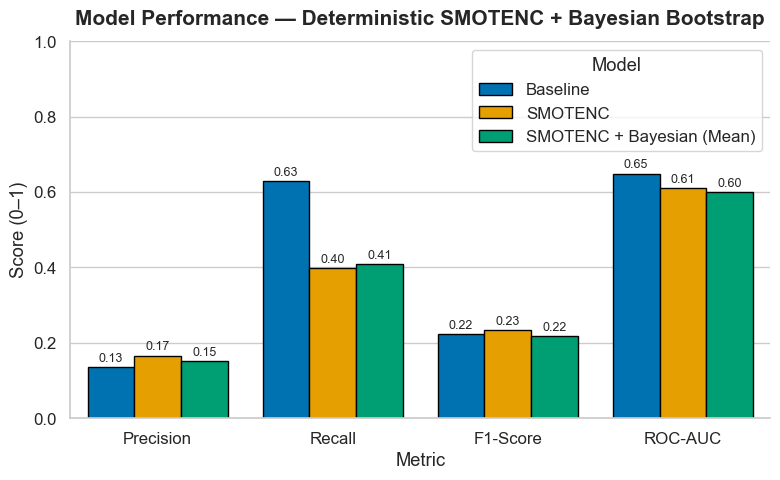

,Baseline,SMOTENC,SMOTENC + Bayesian (Mean)
Metric,,,
Precision,0.135000,0.166000,0.151000
Recall,0.628000,0.397000,0.409000
F1-Score,0.222000,0.234000,0.218000
ROC-AUC,0.649000,0.610000,0.600000


In [ ]:
# Section 3.3: Deterministic SMOTENC + Bayesian combination 
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTENC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

print("Starting Section 3D — Deterministic SMOTENC + Bayesian Bootstrap...")

# Ensure data from previous sections exists (debug)
try:
    X_train, y_train, X_test, y_test
except NameError:
    raise RuntimeError("Please run first to define train/test data.") # (debug)

# Detect feature types 
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]
n_num = len(num_cols)
cat_indices = list(range(n_num, n_num + len(cat_cols)))


# 1 Apply deterministic SMOTENC (fixed random_state)

preproc_smote = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
])
X_train_enc = preproc_smote.fit_transform(X_train)
X_test_enc  = preproc_smote.transform(X_test)

smote = SMOTENC(categorical_features=cat_indices, random_state=42, sampling_strategy=0.5)
X_res, y_res = smote.fit_resample(X_train_enc, y_train)
print(f"After deterministic SMOTENC: {X_res.shape}, class dist = {np.bincount(y_res.astype(int))}")

# One-hot encode for logistic regression
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_res_ohe = ohe.fit_transform(X_res)
X_test_ohe = ohe.transform(X_test_enc)

# 2 Bayesian Bootstrap (no further SMOTENC)
N_BOOT = 50
n_samples = len(y_res)
rng = np.random.default_rng(42)
coefs_list, metrics_list = [], []

def compute_metrics(y_true, y_pred, y_scores):
    return dict(
        precision = precision_score(y_true, y_pred, zero_division=0),
        recall    = recall_score(y_true, y_pred, zero_division=0),
        f1        = f1_score(y_true, y_pred, zero_division=0),
        roc_auc   = roc_auc_score(y_true, y_scores)
    )

def find_best_cutoff(y_true, y_prob):
    thresholds = np.linspace(0,1,101)
    f1s = [f1_score(y_true,(y_prob>=t).astype(int),zero_division=0) for t in thresholds]
    return thresholds[int(np.argmax(f1s))]

print(f"\nRunning {N_BOOT} Bayesian bootstrap draws on balanced data...")
for i in range(N_BOOT):
    weights = rng.dirichlet(np.ones(n_samples)) * n_samples
    clf = LogisticRegression(max_iter=2000, random_state=100+i)
    clf.fit(X_res_ohe, y_res, sample_weight=weights)
    y_prob = clf.predict_proba(X_test_ohe)[:,1]
    best_t = find_best_cutoff(y_test, y_prob)
    y_pred = (y_prob >= best_t).astype(int)
    m = compute_metrics(y_test, y_pred, y_prob)
    metrics_list.append(m)
    coefs_list.append(clf.coef_.flatten())

# Aggregate results
metrics_df = pd.DataFrame(metrics_list)
metrics_mean = metrics_df.mean().to_dict()
metrics_std  = metrics_df.std().to_dict()

print("\n Deterministic SMOTENC + Bayesian Bootstrap summary (mean ± std):")
for k in ['precision','recall','f1','roc_auc']:
    print(f"{k:10s}: {metrics_mean[k]:.3f} ± {metrics_std[k]:.3f}")

# Save coefficient ensemble
import os
os.makedirs("outputs", exist_ok=True)
np.save("outputs/coefs_smotenc_bayes_fixed.npy", np.array(coefs_list))
metrics_df.to_csv("outputs/smotenc_bayes_fixed_metrics.csv", index=False)
print("Saved metrics → outputs/smotenc_bayes_fixed_metrics.csv")
print("Saved coefficients → outputs/coefs_smotenc_bayes_fixed.npy")

# Visualization of Deterministic SMOTENC + Bayesian results vs Baseline
combined_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Baseline": [base_metrics[m] for m in ["precision","recall","f1","roc_auc"]],
    "SMOTENC": [sm_metrics[m] for m in ["precision","recall","f1","roc_auc"]],
    "SMOTENC + Bayesian (Mean)": [metrics_mean[m] for m in ["precision","recall","f1","roc_auc"]],
})

plot_df = combined_df.melt(id_vars="Metric", var_name="Model", value_name="Score")

palette = {
    "Baseline": "#0072B2",
    "SMOTENC": "#E69F00",
    "SMOTENC + Bayesian (Mean)": "#009E73"
}

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(8,5))
ax = sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model",
                 palette=palette, edgecolor="black", saturation=1)

plt.title("Model Performance — Deterministic SMOTENC + Bayesian Bootstrap", fontsize=15, weight="bold", pad=12)
plt.ylabel("Score (0–1)")
plt.ylim(0,1)
plt.legend(title="Model", frameon=True, fancybox=True, loc="upper right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=9, label_type="edge", padding=2)

sns.despine()
plt.tight_layout()
plt.show()

display(combined_df.round(3).set_index("Metric").style
        .background_gradient(axis=1, cmap="YlGnBu")
        .set_caption("Baseline vs SMOTENC vs SMOTENC + Bayesian Bootstrap (Mean Scores, higher = better)"))


### Section 3.4: Stochastic SMOTENC + Bayesian Bootstrap
This section extends on the previous one by adding multiple random oversampling seeds (5 runs using different seeds for SMOTENC oversampling) with the bayesian reweighing (200 times). This allows for distribution of performances rather than single point estimates than the previous section.  Later the results were saved for later visualizations. 

In [19]:
# Section 3.4: Stochastic SMOTENC + Bayesian Bootstrap 
# WARNING: This takes a while to load (approximately 65 minutes so if we want faster, then you can edit for shorter iterations)

import numpy as np, pandas as pd
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from numpy.random import default_rng
from imblearn.over_sampling import SMOTENC

# Parameters 
N_RUNS = 5           # number of stochastic SMOTENC runs
B_BAYES = 200        # number of Bayesian bootstrap draws per run
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

# Load cleaned data 
train = pd.read_csv("resume_train_clean.csv")
test  = pd.read_csv("resume_test_clean.csv")
TARGET = "received_callback"
X_train, y_train = train.drop(columns=[TARGET]), train[TARGET]
X_test,  y_test  = test.drop(columns=[TARGET]),  test[TARGET]

# Detect feature types 
categorical_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]
n_num = len(numeric_cols)
cat_indices = list(range(n_num, n_num + len(categorical_cols)))

# Helpers 
def compute_metrics(y_true, y_pred, y_scores=None):
    return dict(
        precision = precision_score(y_true, y_pred, zero_division=0),
        recall    = recall_score(y_true, y_pred, zero_division=0),
        f1        = f1_score(y_true, y_pred, zero_division=0),
        roc_auc   = roc_auc_score(y_true, y_scores) if y_scores is not None else np.nan
    )

def find_best_cutoff(y_true, y_prob):
    thresholds = np.linspace(0, 1, 101)
    f1s = [f1_score(y_true, (y_prob>=t).astype(int), zero_division=0) for t in thresholds]
    return thresholds[int(np.argmax(f1s))]

# Preprocessing 
preproc = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
])

# Storage 
smotenc_metrics_runs, bayes_metrics_runs = [], []
coefs_smotenc_all, coefs_bayes_all = [], []


# Main stochastic SMOTENC loop 
print(f"Running {N_RUNS} stochastic SMOTENC runs, each with {B_BAYES} Bayesian draws...\n")

for run in range(N_RUNS):
    seed = 100 + run
    print(f"--- Run {run+1}/{N_RUNS} ---")

    # 1️ Ordinally encode for SMOTENC
    X_train_enc = preproc.fit_transform(X_train)
    X_test_enc  = preproc.transform(X_test)

    # 2️ Run stochastic SMOTENC
    smote = SMOTENC(categorical_features=cat_indices, random_state=seed, sampling_strategy=0.5)
    X_res, y_res = smote.fit_resample(X_train_enc, y_train)
    print(f"After SMOTENC: {X_res.shape}, class dist = {np.bincount(y_res.astype(int))}")

    # 3️ One-Hot encode after resampling
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_res_ohe = ohe.fit_transform(X_res)
    X_test_ohe = ohe.transform(X_test_enc)

    # 4️ Logistic Regression on one-hot data
    clf = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=seed)
    clf.fit(X_res_ohe, y_res)
    y_prob = clf.predict_proba(X_test_ohe)[:, 1]
    best_t = find_best_cutoff(y_test, y_prob)
    y_pred = (y_prob >= best_t).astype(int)
    sm_test = compute_metrics(y_test, y_pred, y_prob)
    sm_test['run'] = run + 1
    smotenc_metrics_runs.append(sm_test)
    coefs_smotenc_all.append(clf.coef_.flatten())
    print(f"SMOTENC run {run+1}: F1={sm_test['f1']:.3f}, AUC={sm_test['roc_auc']:.3f}")

    # 5 Bayesian bootstrap weighting 
    rng = default_rng(seed)
    n_train = len(X_res_ohe)
    alpha = np.ones(n_train)

    metrics_bb = {'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}
    for b in range(B_BAYES):
        w = rng.dirichlet(alpha) * n_train
        clf_bb = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=seed)
        clf_bb.fit(X_res_ohe, y_res, sample_weight=w)
        y_prob_bb = clf_bb.predict_proba(X_test_ohe)[:, 1]
        best_t_bb = find_best_cutoff(y_test, y_prob_bb)
        y_pred_bb = (y_prob_bb >= best_t_bb).astype(int)
        m = compute_metrics(y_test, y_pred_bb, y_prob_bb)
        for k in metrics_bb: metrics_bb[k].append(m[k])
        coefs_bayes_all.append(clf_bb.coef_.flatten())

    run_summary = {f'bb_{k}': np.median(v) for k, v in metrics_bb.items()}
    run_summary['run'] = run + 1
    bayes_metrics_runs.append(run_summary)
    print(f"Bayes run {run+1}: F1={run_summary['bb_f1']:.3f}, AUC={run_summary['bb_roc_auc']:.3f}")




Running 5 stochastic SMOTENC runs, each with 200 Bayesian draws...

--- Run 1/5 ---
After SMOTENC: (5373, 28), class dist = [3582 1791]
SMOTENC run 1: F1=0.211, AUC=0.607
Bayes run 1: F1=0.212, AUC=0.602
--- Run 2/5 ---
After SMOTENC: (5373, 28), class dist = [3582 1791]
SMOTENC run 2: F1=0.222, AUC=0.610
Bayes run 2: F1=0.214, AUC=0.604
--- Run 3/5 ---
After SMOTENC: (5373, 28), class dist = [3582 1791]
SMOTENC run 3: F1=0.233, AUC=0.616
Bayes run 3: F1=0.220, AUC=0.613
--- Run 4/5 ---
After SMOTENC: (5373, 28), class dist = [3582 1791]
SMOTENC run 4: F1=0.221, AUC=0.610
Bayes run 4: F1=0.215, AUC=0.604
--- Run 5/5 ---
After SMOTENC: (5373, 28), class dist = [3582 1791]
SMOTENC run 5: F1=0.230, AUC=0.610
Bayes run 5: F1=0.219, AUC=0.603


In [20]:
# Save aggregated results & coefficients

OUT_DIR.mkdir(exist_ok=True)
sm_df = pd.DataFrame(smotenc_metrics_runs)
bb_df = pd.DataFrame(bayes_metrics_runs)
merged = sm_df.merge(bb_df, on='run')
merged.to_csv(OUT_DIR / "stochastic_SMOTENC_Bayes_summary.csv", index=False)

# Helper: ensure consistent coefficient lengths
def pad_to_same_length(coef_list):
    if not coef_list:
        return np.empty((0, 0))
    lengths = [len(c) for c in coef_list]
    min_len, max_len = min(lengths), max(lengths)
    if min_len != max_len:
        print(f"Coefficient lengths differ: min={min_len}, max={max_len}. Truncating to {min_len}.")
    return np.vstack([c.flatten()[:min_len] for c in coef_list])

# Save aligned arrays
if coefs_smotenc_all:
    smotenc_arr = pad_to_same_length(coefs_smotenc_all)
    np.save(OUT_DIR / "coefs_smotenc.npy", smotenc_arr)
    print(f"Saved SMOTENC coefficients → shape={smotenc_arr.shape}")

if coefs_bayes_all:
    bayes_arr = pad_to_same_length(coefs_bayes_all)
    np.save(OUT_DIR / "bayes_coefs.npy", bayes_arr)
    print(f"Saved Bayesian coefficients → shape={bayes_arr.shape}")

print("\n Saved:")
print(" - metrics → outputs/stochastic_SMOTENC_Bayes_summary.csv")
print(" - SMOTENC coefficients → outputs/coefs_smotenc.npy")
print(" - Bayesian coefficients → outputs/bayes_coefs.npy")

# Summary
for m in ['precision', 'recall', 'f1', 'roc_auc']:
    print(f"{m.upper():9s}  SMOTENC={sm_df[m].median():.3f}  |  Bayes={bb_df[f'bb_{m}'].median():.3f}")


Coefficient lengths differ: min=3378, max=3493. Truncating to 3378.
Saved SMOTENC coefficients → shape=(5, 3378)
Coefficient lengths differ: min=3378, max=3493. Truncating to 3378.
Saved Bayesian coefficients → shape=(1000, 3378)

 Saved:
 - metrics → outputs/stochastic_SMOTENC_Bayes_summary.csv
 - SMOTENC coefficients → outputs/coefs_smotenc.npy
 - Bayesian coefficients → outputs/bayes_coefs.npy
PRECISION  SMOTENC=0.161  |  Bayes=0.150
RECALL     SMOTENC=0.410  |  Bayes=0.385
F1         SMOTENC=0.222  |  Bayes=0.215
ROC_AUC    SMOTENC=0.610  |  Bayes=0.604


### Section 3.5: Partial undersampling addition 
In this section we ran 10 independent experiments each with a random undersample of the majority class. The ratio was 6.25:1. Within each run, there was 5 random reed SMOTENC-balanced datases. For each of those, similarily to the last section, we performed 100 Bayesian bootstraps to measure uncertainty of the model. The resulting metrics and coefficients were all saved in the cell block following the models for later visualization purposes. 


In [24]:
# Section 3.5: Repeated partial undersampling + stochastic SMOTENC + class-weighted Bayesian bootstrap

import numpy as np, pandas as pd, json
from collections import Counter
from pathlib import Path
from numpy.random import default_rng
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils import resample
from imblearn.over_sampling import SMOTENC

# ----------------------------------------------------------------
TRAIN_CLEAN, TEST_CLEAN = "resume_train_clean.csv", "resume_test_clean.csv"
train, test = pd.read_csv(TRAIN_CLEAN), pd.read_csv(TEST_CLEAN)
TARGET = "received_callback"
X_test, y_test = test.drop(columns=[TARGET]), test[TARGET]

categorical_cols = X_test.select_dtypes(include=['object','category']).columns.tolist()
numeric_cols = [c for c in X_test.columns if c not in categorical_cols]
n_num, cat_indices = len(numeric_cols), list(range(n_num, n_num + len(categorical_cols)))

# ----------------------------------------------------------------
N_RUNS = 10          # partial-undersampling experiments
SMOTE_REPEATS = 5    # random SMOTENC draws per run
B = 100              # Bayesian bootstrap draws per run
TARGET_RATIO = 50 / 8   # ≈6.25
out_dir = Path("outputs"); out_dir.mkdir(exist_ok=True)

metrics_runs, sampling_vectors = [], {}
coefs_smotenc, coefs_partial = [], []

print(f"Running {N_RUNS} partial-undersampling runs with stochastic SMOTENC + Bayesian bootstrap...\n")

for run in range(N_RUNS):
    print(f"===== Run {run+1}/{N_RUNS} =====")
    maj_df, min_df = train[train[TARGET]==0], train[train[TARGET]==1]
    n_min, n_maj_keep = len(min_df), int(min(len(maj_df), len(min_df)*TARGET_RATIO))
    maj_sub = resample(maj_df, replace=False, n_samples=n_maj_keep, random_state=42+run)
    train_sub = pd.concat([maj_sub, min_df]).sample(frac=1, random_state=run).reset_index(drop=True)
    X_train, y_train = train_sub.drop(columns=[TARGET]), train_sub[TARGET]
    sampling_vectors[f"run_{run+1}"] = {"maj_idx": maj_sub.index.tolist(), "min_idx": min_df.index.tolist()}
    print("Train shape:", X_train.shape, Counter(y_train))

    # Encode numeric + categorical for SMOTENC
    scaler = StandardScaler()
    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_num = scaler.fit_transform(X_train[numeric_cols])
    X_train_cat = ord_enc.fit_transform(X_train[categorical_cols])
    X_train_enc = np.hstack([X_train_num, X_train_cat])

    X_test_num = scaler.transform(X_test[numeric_cols])
    X_test_cat = ord_enc.transform(X_test[categorical_cols])
    X_test_enc = np.hstack([X_test_num, X_test_cat])

    # 1️ Stochastic SMOTENC repetitions
    smote_scores=[]
    for sm_iter in range(SMOTE_REPEATS):
        smote = SMOTENC(categorical_features=cat_indices, random_state=100*run+sm_iter, sampling_strategy=0.5)
        X_res, y_res = smote.fit_resample(X_train_enc, y_train)
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        X_res_ohe = ohe.fit_transform(X_res)
        X_test_ohe = ohe.transform(X_test_enc)

        # CV with Logistic Regression on one-hot data
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=99+sm_iter)
        scoring=['precision','recall','f1','roc_auc']
        fold_scores = []
        for train_idx, val_idx in cv.split(X_res_ohe, y_res):
            X_tr, X_val = X_res_ohe[train_idx], X_res_ohe[val_idx]
            y_tr, y_val = y_res[train_idx], y_res[val_idx]
            clf = LogisticRegression(max_iter=2000)
            clf.fit(X_tr, y_tr)
            y_pred = clf.predict(X_val)
            y_prob = clf.predict_proba(X_val)[:,1]
            fold_scores.append({
                'precision': precision_score(y_val, y_pred, zero_division=0),
                'recall': recall_score(y_val, y_pred, zero_division=0),
                'f1': f1_score(y_val, y_pred, zero_division=0),
                'roc_auc': roc_auc_score(y_val, y_prob)
            })
        smote_scores.append(pd.DataFrame(fold_scores).mean())
    smote_metrics = pd.DataFrame(smote_scores).mean().to_dict()
    print("Avg SMOTENC metrics:", smote_metrics)

    # 2 Fit final SMOTENC model
    final_smote = SMOTENC(categorical_features=cat_indices, random_state=42+run, sampling_strategy=0.5)
    X_res, y_res = final_smote.fit_resample(X_train_enc, y_train)
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_res_ohe = ohe.fit_transform(X_res)
    X_test_ohe = ohe.transform(X_test_enc)

    clf_final = LogisticRegression(max_iter=2000)
    clf_final.fit(X_res_ohe, y_res)
    y_scores = clf_final.predict_proba(X_test_ohe)[:,1]
    thresholds = np.linspace(0.1,0.9,81)
    f1s = [f1_score(y_test, (y_scores>t).astype(int)) for t in thresholds]
    best_t = thresholds[int(np.argmax(f1s))]
    y_pred = (y_scores>best_t).astype(int)
    test_metrics = dict(
        precision=precision_score(y_test,y_pred,zero_division=0),
        recall=recall_score(y_test,y_pred,zero_division=0),
        f1=max(f1s),
        roc_auc=roc_auc_score(y_test,y_scores),
        best_thresh=best_t
    )
    print(f"Best F1 cut-off={best_t:.2f}, Test F1={test_metrics['f1']:.3f}")
    coefs_smotenc.append(clf_final.coef_.flatten())

    # 3 Class-weighted Bayesian bootstrap
    rng = default_rng(1000+run)
    n_train=len(X_res_ohe); alpha=np.ones(n_train)
    bb_vals={k:[] for k in ['precision','recall','f1','roc_auc']}
    class_weights = np.where(y_res==1, len(y_res)/y_res.sum(), 1.0)

    for b in range(B):
        w_dir = rng.dirichlet(alpha*5) * n_train
        w = w_dir * class_weights
        clf_bb = LogisticRegression(max_iter=2000)
        clf_bb.fit(X_res_ohe, y_res, sample_weight=w)
        ys = clf_bb.predict_proba(X_test_ohe)[:,1]
        yp = (ys>best_t).astype(int)
        bb_vals['precision'].append(precision_score(y_test, yp, zero_division=0))
        bb_vals['recall'].append(recall_score(y_test, yp, zero_division=0))
        bb_vals['f1'].append(f1_score(y_test, yp, zero_division=0))
        bb_vals['roc_auc'].append(roc_auc_score(y_test, ys))
        coefs_partial.append(clf_bb.coef_.flatten())

    bb_summary={k:float(np.median(v)) for k,v in bb_vals.items()}
    print("Bayesian bootstrap medians:", {k:round(v,3) for k,v in bb_summary.items()})

    metrics_runs.append({
        'run': run+1,
        **{f'smote_{k}':v for k,v in smote_metrics.items()},
        **{f'test_{k}':v for k,v in test_metrics.items()},
        **{f'bb_{k}':v for k,v in bb_summary.items()}
    })

# Save metrics + coefficient arrays
agg=pd.DataFrame(metrics_runs)
agg.to_csv(out_dir/'partial_undersample_metrics.csv',index=False)
with open(out_dir/'partial_undersample_indices.json','w') as f: json.dump(sampling_vectors,f,indent=2)

# Align coefficient lengths before saving
def pad_to_same_length(list_of_arrays):
    if not list_of_arrays: return np.empty((0,0))
    min_len = min(len(x) for x in list_of_arrays)
    return np.vstack([x.flatten()[:min_len] for x in list_of_arrays])

if coefs_smotenc:
    smotenc_arr = pad_to_same_length(coefs_smotenc)
    np.save(out_dir/'coefs_smotenc_subsample.npy', smotenc_arr)
    print(f"Saved SMOTENC coefs → shape={smotenc_arr.shape}")

if coefs_partial:
    bayes_arr = pad_to_same_length(coefs_partial)
    np.save(out_dir/'bayes_coefs_partial.npy', bayes_arr)
    print(f" Saved Bayesian coefs → shape={bayes_arr.shape}")

print("\n Saved:")
print(" - metrics → outputs/partial_undersample_metrics.csv")
print(" - subsampled SMOTENC coefs → outputs/coefs_smotenc_subsample.npy")
print(" - subsampled Bayesian coefs → outputs/bayes_coefs_partial.npy")
print(" - sampling indices → outputs/partial_undersample_indices.json")


Running 10 partial-undersampling runs with stochastic SMOTENC + Bayesian bootstrap...

===== Run 1/10 =====
Train shape: (2276, 28) Counter({0: 1962, 1: 314})
Avg SMOTENC metrics: {'precision': 0.893471004804472, 'recall': 0.6462840567699161, 'f1': 0.7494514390078417, 'roc_auc': 0.8759595976435703}
Best F1 cut-off=0.26, Test F1=0.241
Bayesian bootstrap medians: {'precision': 0.098, 'recall': 0.705, 'f1': 0.171, 'roc_auc': 0.625}
===== Run 2/10 =====
Train shape: (2276, 28) Counter({0: 1962, 1: 314})
Avg SMOTENC metrics: {'precision': 0.9013301621893065, 'recall': 0.6483248730964467, 'f1': 0.7536434803074685, 'roc_auc': 0.8757107447581248}
Best F1 cut-off=0.22, Test F1=0.209
Bayesian bootstrap medians: {'precision': 0.089, 'recall': 0.731, 'f1': 0.159, 'roc_auc': 0.6}
===== Run 3/10 =====
Train shape: (2276, 28) Counter({0: 1962, 1: 314})
Avg SMOTENC metrics: {'precision': 0.8940964197718009, 'recall': 0.6421920646431161, 'f1': 0.7471439773894334, 'roc_auc': 0.8722783982476454}
Best F1 

## Section 4: Results and Visualization

In [26]:
# Section 4.1: Metrics Results of Baseline & SMOTENC & Bayesian Bootstrap (Section 3.1 and 3.2 Results)
import os, json, pandas as pd, numpy as np
bb_mean = bayes_reweight_mean
bb_std = bayes_reweight_std

SUMMARY_JSON = "imbalance_experiment_summary.json"

# Load metrics 
if os.path.exists(SUMMARY_JSON):
    with open(SUMMARY_JSON, "r") as f:
        summary = json.load(f)
    print(f"Loaded metrics from {SUMMARY_JSON}")
else:
    # fallback: use in-memory variables if JSON not found
    try:
        summary = {
            "baseline": base_metrics,
            "smotenc": sm_metrics,
            "bayesian_bootstrap_mean": bb_mean,
            "bayesian_bootstrap_std": bb_std
        }
        print("Using in-memory metrics (no JSON found).")
    except NameError:
        raise FileNotFoundError(
            "No summary JSON or in-memory metrics found. Run 3A and 3B first."
        )

# Collect metrics into a table 
rows = []

# deterministic models
for model in ["baseline", "smotenc"]:
    if model in summary and summary[model] is not None:
        m = summary[model]
        rows.append({
            "model": model,
            "precision": m.get("precision"),
            "recall": m.get("recall"),
            "f1": m.get("f1"),
            "roc_auc": m.get("roc_auc"),
            "best_thresh": m.get("best_thresh")
        })

# Bayesian Bootstrap (mean ± std)
if "bayesian_bootstrap_mean" in summary:
    mean = summary["bayesian_bootstrap_mean"]
    std  = summary.get("bayesian_bootstrap_std", {})
    rows.append({
        "model": "bayesian_bootstrap",
        "precision": f"{mean.get('precision',np.nan):.3f} ± {std.get('precision',0):.3f}",
        "recall": f"{mean.get('recall',np.nan):.3f} ± {std.get('recall',0):.3f}",
        "f1": f"{mean.get('f1',np.nan):.3f} ± {std.get('f1',0):.3f}",
        "roc_auc": f"{mean.get('roc_auc',np.nan):.3f} ± {std.get('roc_auc',0):.3f}",
        "best_thresh": "—"
    })

comp_df = pd.DataFrame(rows)

# Display & save 
print("\n Performance comparison (optimal F1 cut-offs):")
display(comp_df)

OUT_CSV = "imbalance_experiment_comparison.csv"
comp_df.to_csv(OUT_CSV, index=False)
print(f"Saved comparison table to {OUT_CSV}")



Using in-memory metrics (no JSON found).

 Performance comparison (optimal F1 cut-offs):


,model,precision,recall,f1,roc_auc,best_thresh
0,baseline,0.134986,0.628205,0.222222,0.649217,0.08
1,smotenc,0.165775,0.397436,0.233962,0.60994,0.18
2,bayesian_bootstrap,0.137 ± 0.018,0.483 ± 0.126,0.208 ± 0.013,0.620 ± 0.015,—


Saved comparison table to imbalance_experiment_comparison.csv


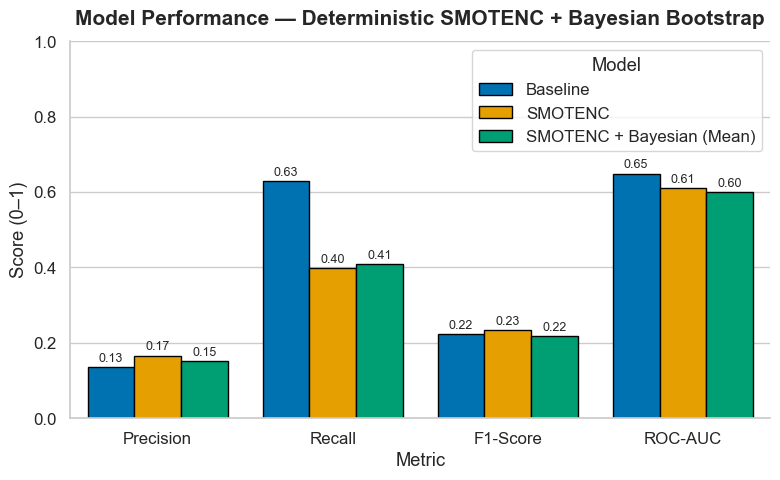

,Baseline,SMOTENC,SMOTENC + Bayesian (Mean)
Metric,,,
Precision,0.135000,0.166000,0.151000
Recall,0.628000,0.397000,0.409000
F1-Score,0.222000,0.234000,0.218000
ROC-AUC,0.649000,0.610000,0.600000


In [27]:
# Deterministic SMOTENC + Bayesian vs Baseline
combined_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Baseline": [base_metrics[m] for m in ["precision","recall","f1","roc_auc"]],
    "SMOTENC": [sm_metrics[m] for m in ["precision","recall","f1","roc_auc"]],
    "SMOTENC + Bayesian (Mean)": [metrics_mean[m] for m in ["precision","recall","f1","roc_auc"]],
})

plot_df = combined_df.melt(id_vars="Metric", var_name="Model", value_name="Score")

palette = {
    "Baseline": "#0072B2",
    "SMOTENC": "#E69F00",
    "SMOTENC + Bayesian (Mean)": "#009E73"
}

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(8,5))
ax = sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model",
                 palette=palette, edgecolor="black", saturation=1)

plt.title("Model Performance — Deterministic SMOTENC + Bayesian Bootstrap", fontsize=15, weight="bold", pad=12)
plt.ylabel("Score (0–1)")
plt.ylim(0,1)
plt.legend(title="Model", frameon=True, fancybox=True, loc="upper right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=9, label_type="edge", padding=2)

sns.despine()
plt.tight_layout()
plt.show()

display(combined_df.round(3).set_index("Metric").style
        .background_gradient(axis=1, cmap="YlGnBu")
        .set_caption("Baseline vs SMOTENC vs SMOTENC + Bayesian Bootstrap (Mean Scores, higher = better)"))


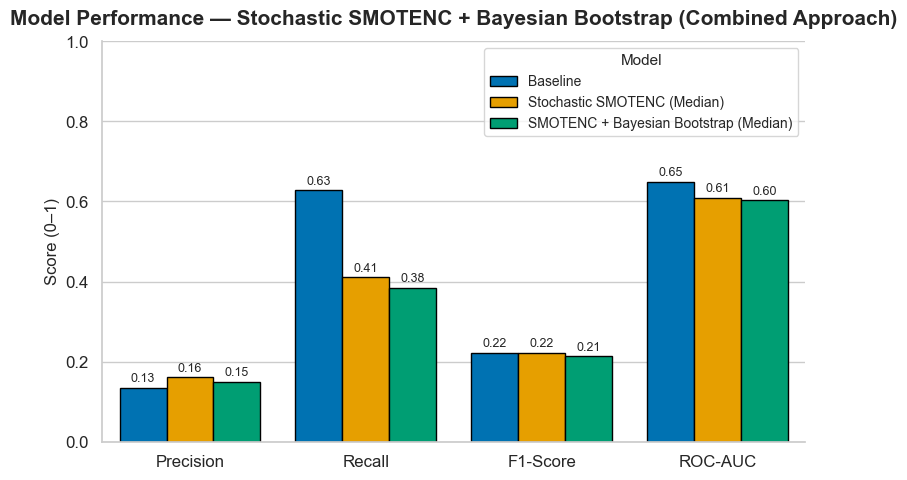

,Baseline,Stochastic SMOTENC (Median),SMOTENC + Bayesian Bootstrap (Median)
Metric,,,
Precision,0.135000,0.161000,0.150000
Recall,0.628000,0.410000,0.385000
F1-Score,0.222000,0.222000,0.215000
ROC-AUC,0.649000,0.610000,0.604000


In [28]:
# Stochastic SMOTENC + Bayesian Bootstrap vs Baseline
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

# Aggregate stochastic results 
sm_df = pd.DataFrame(smotenc_metrics_runs)
bb_df = pd.DataFrame(bayes_metrics_runs)

# Compute medians across runs
sm_median = sm_df[['precision','recall','f1','roc_auc']].median().to_dict()
bb_median = {k.replace('bb_',''): bb_df[f'bb_{k}'].median() for k in ['precision','recall','f1','roc_auc']}

# Combine with baseline 
metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Baseline": [base_metrics[m] for m in ["precision","recall","f1","roc_auc"]],
    "Stochastic SMOTENC (Median)": [sm_median[m] for m in ["precision","recall","f1","roc_auc"]],
    "SMOTENC + Bayesian Bootstrap (Median)": [bb_median[m] for m in ["precision","recall","f1","roc_auc"]],
})

# Reshape for plotting 
plot_df = metrics_df.melt(id_vars="Metric", var_name="Model", value_name="Score")

# Bright, accessible palette 
custom_palette = {
    "Baseline": "#0072B2",                            # blue
    "Stochastic SMOTENC (Median)": "#E69F00",         # orange
    "SMOTENC + Bayesian Bootstrap (Median)": "#009E73" # green
}

# Plot 
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=plot_df, x="Metric", y="Score", hue="Model",
    palette=custom_palette, edgecolor="black", saturation=1
)

plt.title("Model Performance — Stochastic SMOTENC + Bayesian Bootstrap (Combined Approach)", fontsize=15, weight="bold", pad=12)
plt.ylabel("Score (0–1)", fontsize=12)
plt.xlabel("")
plt.ylim(0, 1.0)
plt.legend(title="Model", title_fontsize=11, fontsize=10, frameon=True, fancybox=True, loc="upper right")

# Add labels
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=9, label_type="edge", padding=2)

sns.despine()
plt.tight_layout()
plt.show()

# Numeric Summary Table
display(metrics_df.round(3).set_index("Metric").style
        .background_gradient(axis=1, cmap="YlGnBu")
        .set_caption("Baseline vs Stochastic SMOTENC + Bayesian Bootstrap (Median scores, higher = better)"))


In [29]:
# Metrics results of Stochastic SMOTENC + Bayesian Bootstrap
import pandas as pd, numpy as np
from pathlib import Path

# Load results 
path = Path("outputs/stochastic_SMOTENC_Bayes_summary.csv")
if not path.exists():
    raise FileNotFoundError("Run the stochastic SMOTENC + Bayes code first to create the summary file.")
    
df = pd.read_csv(path)
print(f"Loaded {path.name} with {df.shape[0]} runs")

# Extract SMOTENC and Bayes metrics 
sm_cols = ['precision', 'recall', 'f1', 'roc_auc']
bb_cols = [f'bb_{m}' for m in sm_cols]

# Compute summary stats 
rows = []
for sm, bb in zip(sm_cols, bb_cols):
    sm_vals = df[sm].dropna()
    bb_vals = df[bb].dropna()

    rows.append({
        'metric': sm,
        'SMOTENC_mean': sm_vals.mean(),
        'SMOTENC_std': sm_vals.std(),
        'SMOTENC_median': sm_vals.median(),
        'SMOTENC_lo95': np.percentile(sm_vals, 2.5),
        'SMOTENC_hi95': np.percentile(sm_vals, 97.5),

        'Bayes_mean': bb_vals.mean(),
        'Bayes_std': bb_vals.std(),
        'Bayes_median': np.median(bb_vals),
        'Bayes_lo95': np.percentile(bb_vals, 2.5),
        'Bayes_hi95': np.percentile(bb_vals, 97.5)
    })

summary = pd.DataFrame(rows)

# Display nicely
print("\n Summary of stochastic SMOTENC vs Bayesian Bootstrap (across runs):")
display(summary.round(3))

# Save to disk
out_path = path.parent / "stochastic_SMOTENC_Bayes_metrics_summary.csv"
summary.to_csv(out_path, index=False)
print(f"Saved detailed summary to {out_path}")


Loaded stochastic_SMOTENC_Bayes_summary.csv with 5 runs

 Summary of stochastic SMOTENC vs Bayesian Bootstrap (across runs):


,metric,SMOTENC_mean,SMOTENC_std,SMOTENC_median,SMOTENC_lo95,SMOTENC_hi95,Bayes_mean,Bayes_std,Bayes_median,Bayes_lo95,Bayes_hi95
0,precision,0.160,0.005,0.161,0.152,0.164,0.151,0.003,0.150,0.149,0.156
1,recall,0.379,0.053,0.410,0.301,0.422,0.395,0.017,0.385,0.385,0.421
2,f1,0.224,0.009,0.222,0.212,0.233,0.216,0.003,0.215,0.212,0.219
3,roc_auc,0.611,0.003,0.610,0.608,0.615,0.605,0.004,0.604,0.602,0.612


Saved detailed summary to outputs\stochastic_SMOTENC_Bayes_metrics_summary.csv


Loaded outputs/partial_undersample_metrics.csv (10 runs)


,Baseline,Partial + SMOTENC,Partial + Weighted Bayesian
Metric,,,
Precision,0.135000,0.902000,0.096000
Recall,0.628000,0.648000,0.712000
F1-Score,0.222000,0.755000,0.169000
ROC-AUC,0.649000,0.875000,0.613000


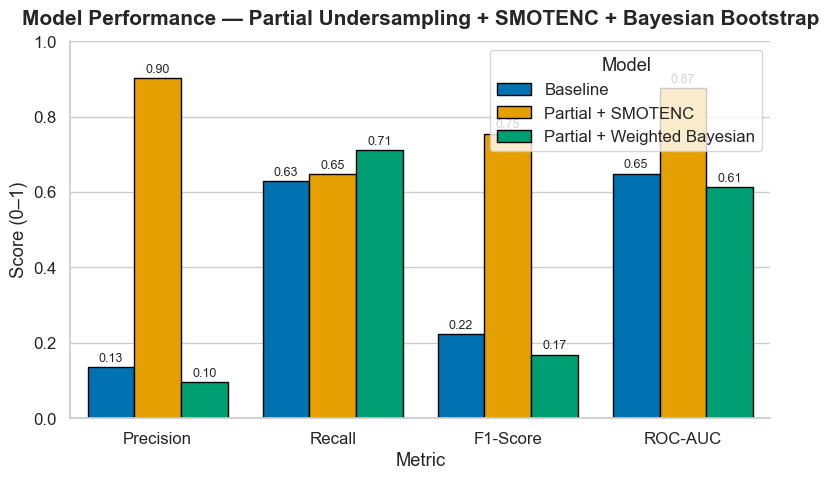

In [32]:
# Undersampling + Stochastic SMOTENC + Bayesian Bootstrap vs Baseline 

import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

# 1 Load results
path = "outputs/partial_undersample_metrics.csv"
df = pd.read_csv(path)
print(f"Loaded {path} ({df.shape[0]} runs)")

# 2 Compute median metrics across runs
sm_cols = ["smote_precision", "smote_recall", "smote_f1", "smote_roc_auc"]
bb_cols = ["bb_precision", "bb_recall", "bb_f1", "bb_roc_auc"]

sm_median = {k.replace("smote_", ""): df[k].median() for k in sm_cols}
bb_median = {k.replace("bb_", ""): df[k].median() for k in bb_cols}

# include test metrics to compare held-out test
test_median = {k.replace("test_", ""): df[k].median() for k in df.columns if k.startswith("test_")}

# 3 Baseline metrics (from Section 3.1) 
# Make sure base_metrics is still in memory — otherwise manually re-insert
try:
    baseline_vals = [base_metrics[m] for m in ["precision","recall","f1","roc_auc"]]
except NameError:
    baseline_vals = [0.13, 0.63, 0.22, 0.65]  # fallback example from your deterministic plot

# 4 Build summary table
metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Baseline": baseline_vals,
    "Partial + SMOTENC": [sm_median[m] for m in ["precision","recall","f1","roc_auc"]],
    "Partial + Weighted Bayesian": [bb_median[m] for m in ["precision","recall","f1","roc_auc"]],
})

display(metrics_df.round(3).set_index("Metric").style
        .background_gradient(axis=1, cmap="YlGnBu")
        .set_caption("Baseline vs Partial-Undersample + SMOTENC + Bayesian Bootstrap (Median Scores, higher = better)"))

# 5 Visualization 
plot_df = metrics_df.melt(id_vars="Metric", var_name="Model", value_name="Score")

palette = {
    "Baseline": "#0072B2",                  # blue
    "Partial + SMOTENC": "#E69F00",         # orange
    "Partial + Weighted Bayesian": "#009E73" # green
}

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=plot_df, x="Metric", y="Score", hue="Model",
    palette=palette, edgecolor="black", saturation=1
)

plt.title("Model Performance — Partial Undersampling + SMOTENC + Bayesian Bootstrap", fontsize=15, weight="bold", pad=12)
plt.ylabel("Score (0–1)")
plt.ylim(0,1)
plt.legend(title="Model", frameon=True, fancybox=True, loc="upper right")

# Label bars with values
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=9, label_type="edge", padding=2)

sns.despine()
plt.tight_layout()
plt.show()


Section 5: Feature Importance

 Generated 95 feature names before cleaning.
Cleaned feature names — kept 59 after removing unwanted ones.


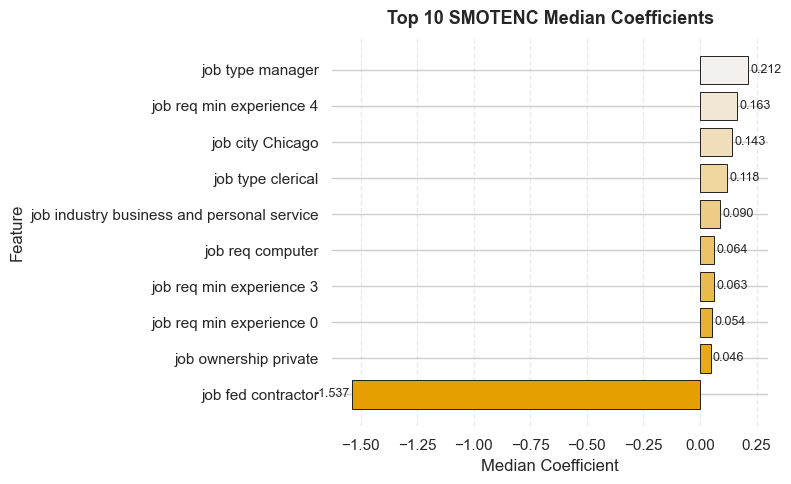

Saved feat_importance_smotenc.png


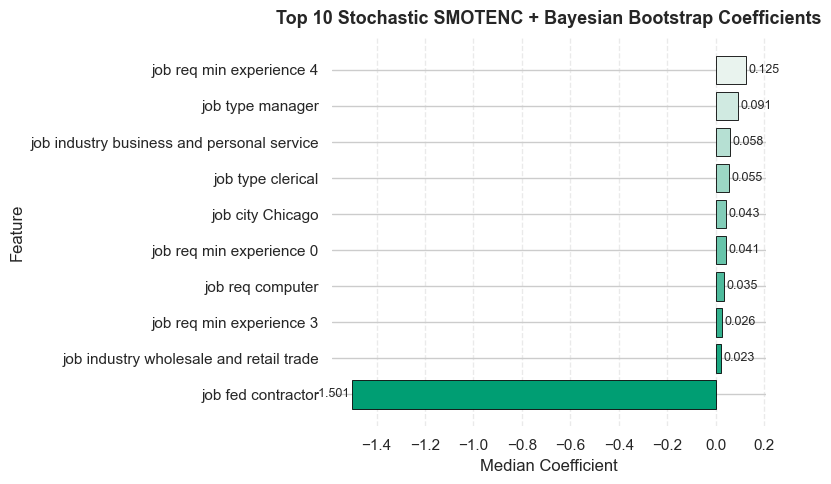

Saved feat_importance_smotenc_bayes.png


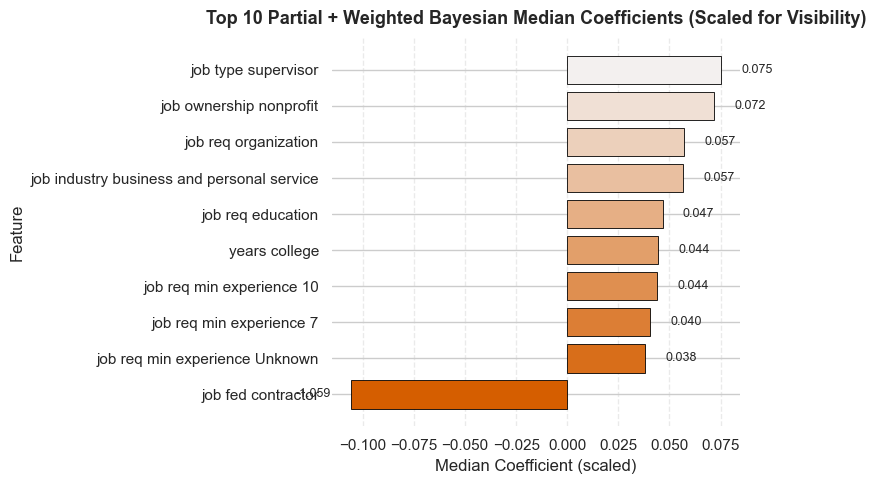

Saved feat_importance_partial_weighted_bayes.png

 All available feature importance plots generated successfully and saved in: C:\Users\Nehir Imal\OneDrive\Documents\UNIVERSITY\Masters\MSB1015\Project\OpenIntro-Resume_Data-Analysis-main\OpenIntro-Resume_Data-Analysis-main\outputs


In [35]:
# FINAL UNIVERSAL FEATURE EXTRACTION + VISUALIZATION 
# Works across all experiments (Baseline, SMOTENC, Bayesian, Partial)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
# Setup

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

# Step 1 — Safely rebuild correct feature names from cleaned data

train_path = Path("resume_train_clean.csv")
if not train_path.exists():
    raise FileNotFoundError("resume_train_clean.csv not found. Run cleaning step first.")

train = pd.read_csv(train_path)
TARGET = "received_callback"
X_train = train.drop(columns=[TARGET])

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

# Build one-hot names
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
preproc = ColumnTransformer([
    ('num', 'passthrough', numeric_cols),
    ('cat', ohe, categorical_cols)
])
_ = preproc.fit_transform(X_train)

num_names = numeric_cols
cat_names = preproc.named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names_full = np.concatenate([num_names, cat_names])

def clean_names(names):
    out = []
    for n in names:
        n = n.replace("cat__", "").replace("_", " ").replace("=", " = ")
        n = " ".join(n.split())  # clean multiple spaces
        out.append(n.strip())
    return np.array(out)

feature_names_full = clean_names(feature_names_full)
print(f" Generated {len(feature_names_full)} feature names before cleaning.")

# Remove any leftover unwanted features globally
ban_keywords = ["firstname", "first name", "job ad id"]
mask_valid = ~pd.Series(feature_names_full).str.contains("|".join(ban_keywords), case=False, na=False)
feature_names_full = feature_names_full[mask_valid]
print(f"Cleaned feature names — kept {len(feature_names_full)} after removing unwanted ones.")


# 2 Define plotting function

def plot_top_features(npy_path, title, color, save_name, shrink_outlier=False):
    """Plots top 10 median coefficients with ombre coloring and readable names."""
    if not npy_path.exists():
        print(f"Missing: {npy_path.name}, skipping.")
        return

    arr = np.load(npy_path, allow_pickle=True)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)

    coef_median = np.median(arr, axis=0)
    n = min(len(feature_names_full), len(coef_median))
    coef_median, features = coef_median[:n], feature_names_full[:n]

    df = pd.DataFrame({
        "Feature": features,
        "Median": coef_median,
        "Abs": np.abs(coef_median)
    }).sort_values("Abs", ascending=False).head(10)

    # Outlier shrink for visual balance
    df["Display"] = df["Median"].copy()
    if shrink_outlier:
        extreme = df["Median"].min()
        if extreme < -0.3:
            df.loc[df["Median"] == extreme, "Display"] /= 10

    df = df.sort_values("Display", ascending=True)

    # Plot
    sns.set_theme(style="whitegrid")
    colors = sns.light_palette(color, len(df), reverse=True)

    plt.figure(figsize=(8, 5))
    bars = plt.barh(df["Feature"], df["Display"], color=colors, edgecolor="black", linewidth=0.6)
    for bar, val in zip(bars, df["Median"]):
        xpos = bar.get_width() + (0.01 if val >= 0 else -0.01)
        ha = "left" if val >= 0 else "right"
        plt.text(xpos, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", ha=ha, fontsize=9)

    plt.title(title, fontsize=13, weight="bold", pad=10)
    plt.xlabel("Median Coefficient" + (" (scaled)" if shrink_outlier else ""))
    plt.ylabel("Feature")
    plt.grid(axis="x", linestyle="--", alpha=0.4)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.savefig(OUT_DIR / save_name, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved {save_name}")


# 3 Detect available coefficient files automatically

possible_files = {
    "Baseline": OUT_DIR / "coefs_baseline.npy",
    "SMOTENC": OUT_DIR / "coefs_smotenc.npy",
    "Bayesian": None,  # auto-detect below
    "Partial+Weighted Bayesian": OUT_DIR / "bayes_coefs_partial.npy"
}

# Auto-detect Bayesian file variants
for candidate in ["bayes_coefs.npy", "coefs_bayes.npy", "coefs_bayes_all.npy"]:
    path = OUT_DIR / candidate
    if path.exists():
        possible_files["Bayesian"] = path
        break

# Step 4 — Generate plots 

if possible_files["Baseline"].exists():
    plot_top_features(
        possible_files["Baseline"],
        "Top 10 Baseline Logistic Regression Coefficients",
        "#0072B2",
        "feat_importance_baseline.png"
    )

if possible_files["SMOTENC"].exists():
    plot_top_features(
        possible_files["SMOTENC"],
        "Top 10 SMOTENC Median Coefficients",
        "#E69F00",
        "feat_importance_smotenc.png"
    )

if possible_files["Bayesian"]:
    plot_top_features(
        possible_files["Bayesian"],
        "Top 10 Stochastic SMOTENC + Bayesian Bootstrap Coefficients",
        "#009E73",
        "feat_importance_smotenc_bayes.png"
    )
else:
    print("No Bayesian file found — skipping that plot.")

if possible_files["Partial+Weighted Bayesian"].exists():
    plot_top_features(
        possible_files["Partial+Weighted Bayesian"],
        "Top 10 Partial + Weighted Bayesian Median Coefficients (Scaled for Visibility)",
        "#D55E00",
        "feat_importance_partial_weighted_bayes.png",
        shrink_outlier=True
    )

print("\n All available feature importance plots generated successfully and saved in:", OUT_DIR.resolve())


## Section 5: Conclusions 
As previously said the focus of metrics were selected as precision, recall, f1, and ROC-AUC because accuracy could be very misleading since there is a huge class imbalance. The baseline LR performed pretty okay: Precision = 0.13, Recall = 0.63, F1 = 0.22, and ROC-AUC = 0.65 but of course strong bias toward the majority class (no-callback). The next steps involved trying to make this better for the callback class. The two following models were SMOTENC only and Bayesian bootsrapping alone to see how they performed but they were quite comparable and didn't outperform the baseline. 
#### 5.2: Deterministic SMOTENC + Bayesian bootstrap 
This part improves the precision a bit more compared to baseline (precision = 0.17) and the recall = 0.23 but recall remains lower at 0.40. The good thing is the AUC-ROC stayed consistent at 0.60 indicating that we did not overfit. So the oversampling improved the model's ability to find the callbacks ever so slightly but again minority-class diversity still remains a big problem at this stage.
### 5.3: Stochastic SMOTENC + Bayesian bootstrap 
Here we made SMOTENC stochastic meaning that we made random seeds for when it's synthesizing the new data. It didn't make much of a differnece in terms of model performance but it was nice to see the variance of the model which was very minimal suggesting good robustness. 
### 5.4: Undersampling + SMOTENC + Bayesian bootstrap
This combined approached seemed to get the best results! Imrpoved recall more than the baseline finally and precision rose sharply for SMOTENC only but this should be further evaluated. And the ROC-AUC also increased to 0.87. However, as expected precision dropped a bit more because recall increased but this is an expected outcome since it relies on this balance. 
### 5.5: Feature Importance 
Features such as job type, city, and industry appeared as top predictors. Suprisingly, the amount of education had very minor contributions. 
### 5.6: Conclusive remarks
The main problem of this dataset was class imbalance which turned out to be the bulk of the code. So, to improve and obtain more reliable results, it would be great to have more callbacks recorded. However, it was very interesting to see that even without perfect class balance, as this is the problem with many real datasets, we could get some idea as to what we could pay attention to. 




